In [2]:
%load_ext autoreload
# %reload_ext autoreload
%autoreload 1

%aimport b6_epilepsies 
import b6_epilepsies as b6 #.py file in the same dir as this .ipynb
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# sns.set_theme(style="whitegrid", context="notebook", palette="muted")

# Define the custom color palette and genotype order
# new_colors_order = sns.color_palette(palette='Set2', n_colors=3)
# new_colors_order[0], new_colors_order[1], new_colors_order[2] = new_colors_order[1], new_colors_order[0], new_colors_order[2]
# color_map = dict(zip(['wt', 'het', 'hom'], new_colors_order))

# Define input variables
date   = "250214"
box1   = "14"
box2   = "15"
exp    = "ALDH7A1_20LYS_7dpf"
export = False

omit = {box1:['H7','D8','D9','D12']}
    
ald_lys_obj_raw = b6.RawData(date, box1, box2, exp, export) #.prepped_data attribute to access df

# ald_lys_obj_mid  = b6.MiddurData(date, box1, box2, exp, export, omit=omit) #.prepped_data attribute to access df


Initialising RawData...
Start of experiment: 2025-02-14 10:07:08
Instantiated using 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv, no need to prepare raw data.
Done.


In [7]:
df_mid, df_filtered_mid = ald_lys_obj_mid.prepped_data, ald_lys_obj_mid.prepped_filtered_data

In [18]:
ald_lys_obj_mid.quick_plot_per_fish()

NameError: name 'ald_lys_obj_mid' is not defined

In [ ]:
grouped_df_filtered = df_filtered_mid.groupby(['genotype','stdate_sttime'])['middur'].agg(['mean', 'median', 'std', 'min', 'max', 'count','sum'])


plot_timeseries(grouped_df_filtered)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_timeseries(grouped_df_filtered):
    ungrouped = grouped_df_filtered.reset_index()

    # Plot using seaborn
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=ungrouped,
        x='stdate_sttime',  # x-axis: timestamps
        y='mean',           # y-axis: the mean of 'middur'
        hue='genotype',     # Different lines for each genotype
        hue_order = ['WT','HET','HOM'],
        linewidth=1,
        palette=new_colors_order
    )
    
    
    # Customize the x-axis format
    ax = plt.gca()  # Get the current axes
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Automatically locate date ticks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as 'Date on one line, Time on the next'
    
    # Customize plot
    plt.title("ALDH7A1: Average Activity Over Time per Genotype (Filtered)")
    plt.xlabel("Timestamp")
    plt.ylabel("Mean Activity (s/min)")
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend(title="Genotype")
    plt.grid(True)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

    
    ### Smooth plot
    
    # Apply a rolling average for smoothing
    ungrouped['smoothed_mean'] = ungrouped.groupby('genotype')['mean'].apply(
        lambda x: x.rolling(window=40, min_periods=1).mean()
    )
    
    # Calculate Standard Error (SE)
    ungrouped['se'] = ungrouped['std'] / np.sqrt(ungrouped['count'])
    
    # Plot using seaborn
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=ungrouped,
        x='stdate_sttime',  # x-axis: timestamps
        y='smoothed_mean',           # y-axis: the mean of 'middur'
        hue_order=['WT','HET','HOM'],
        hue='genotype',     # Different lines for each genotype
        linewidth=1,
        ci=None,
        palette=new_colors_order
    )
    
    
    # Add shaded standard error for each genotype
    for genotype, group in ungrouped.groupby('genotype'):
        # print(genotype, group)
        plt.fill_between(
            group['stdate_sttime'],
            group['smoothed_mean'] - group['se'],  # Lower bound (mean - SE)
            group['smoothed_mean'] + group['se'],  # Upper bound (mean + SE)
            color = color_map[genotype],
            alpha=0.2,                             # Transparency for the shading
            label=f"{genotype} SE"          # Label for the spread
        )
    
    # Customize the x-axis format
    ax = plt.gca()  # Get the current axes
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # Automatically locate date ticks
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as 'Date on one line, Time on the next'
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))  # Format as 'Date on one line, Time on the next'

    
    # Customize plot
    plt.title("Smoothed Average Activity Over Time with Standard Error")
    plt.xlabel("Timestamp")
    plt.ylabel("Smoothed Average Activity (s/min)")
    plt.xticks(rotation=45)
    # plt.legend(title="Genotype and SE Spread")
    
    
    
    plt.grid(True)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

In [22]:
df_raw = ald_lys_obj_raw.df
# df_raw_14 = df_raw[df_raw['box']=='14']
# df_raw.to_csv('250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_processed.csv')
# df_raw_test.drop(columns=['zhrs', 'exsecs','abstime', 'time','type','plate','location'])
# df_raw_test.head(50)

# type(df_raw_test['box'])
# df_raw_test['box']

Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_single_plot_C2.svg


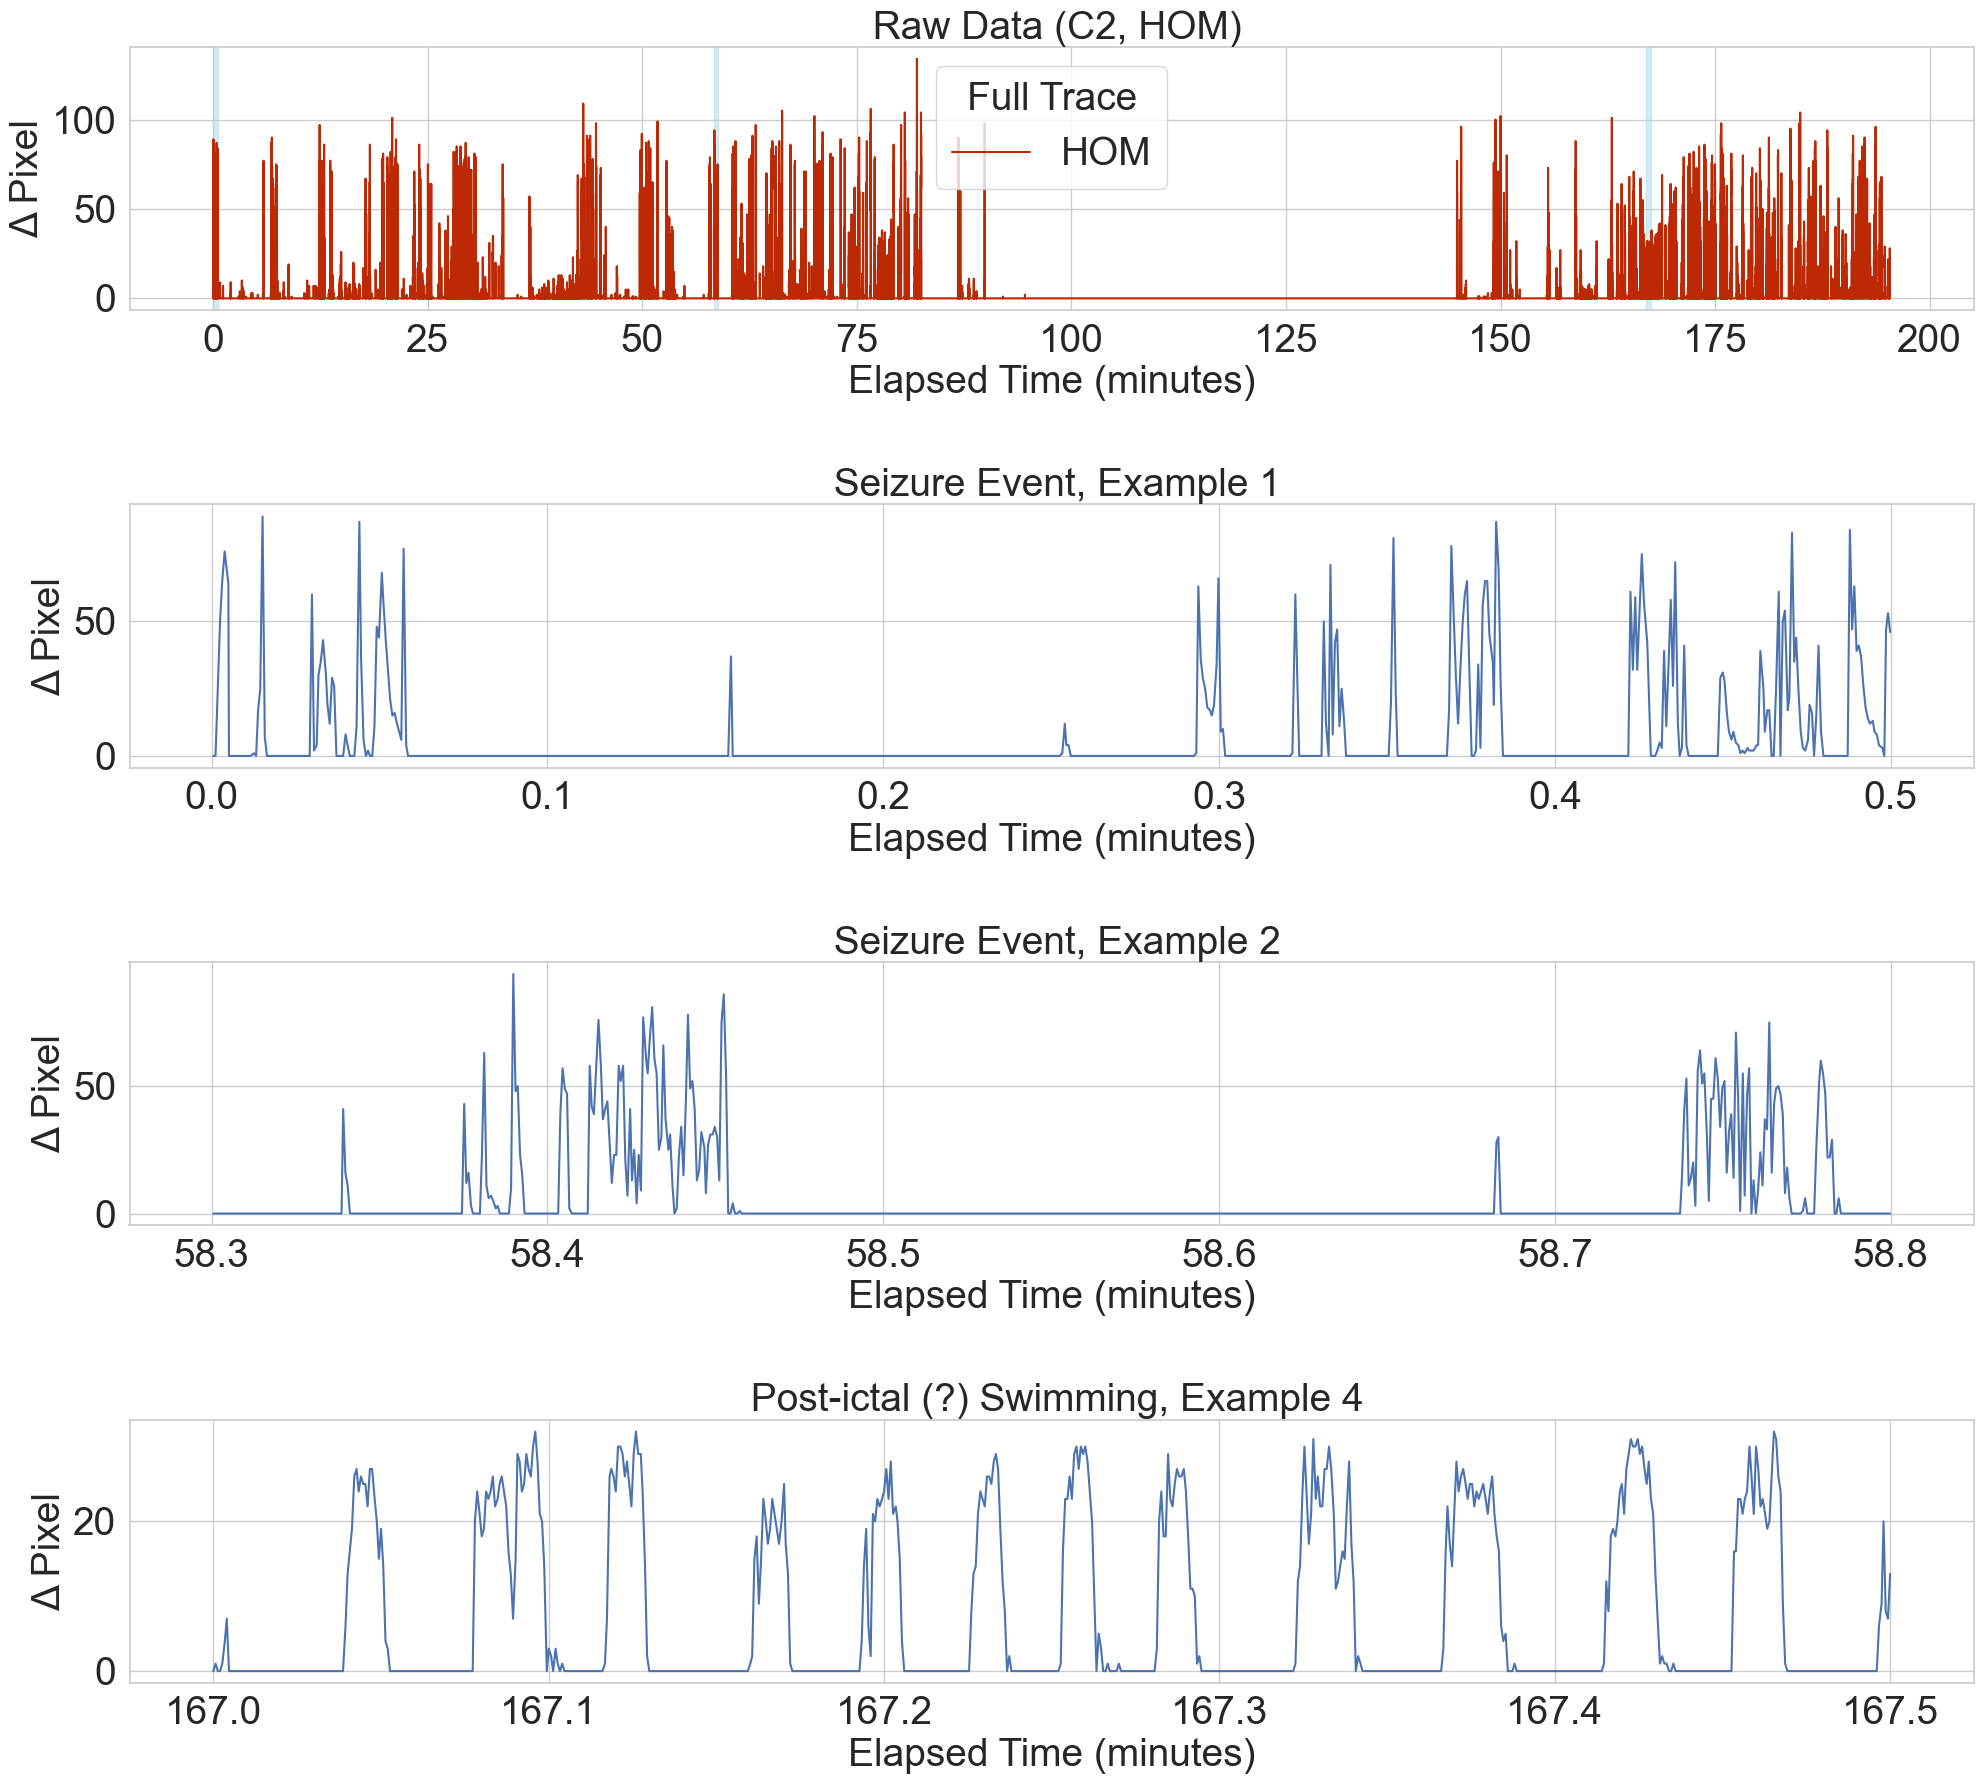

In [17]:
ald_lys_obj_raw.plot_single_fish_activity(well='C2', event_windows=[
    (0, 0.5, "Seizure Event, Example 1"),
    (58.3, 58.8, "Seizure Event, Example 2"),
    # (145, 145.5, "Seizure Event, Example 3"),
    (167, 167.5, "Post-ictal (?) Swimming, Example 4")
])

# ald_lys_obj_raw.plot_single_fish_activity(well='A3', event_windows=[
#     (20, 20.5, "Example 1"),
#     (80.3, 80.8, "Example 2"),
#     (130, 130.5, "Example 3"),
#     (160, 160.5, "Example 4")
# ])



Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_single_plot_A1.svg


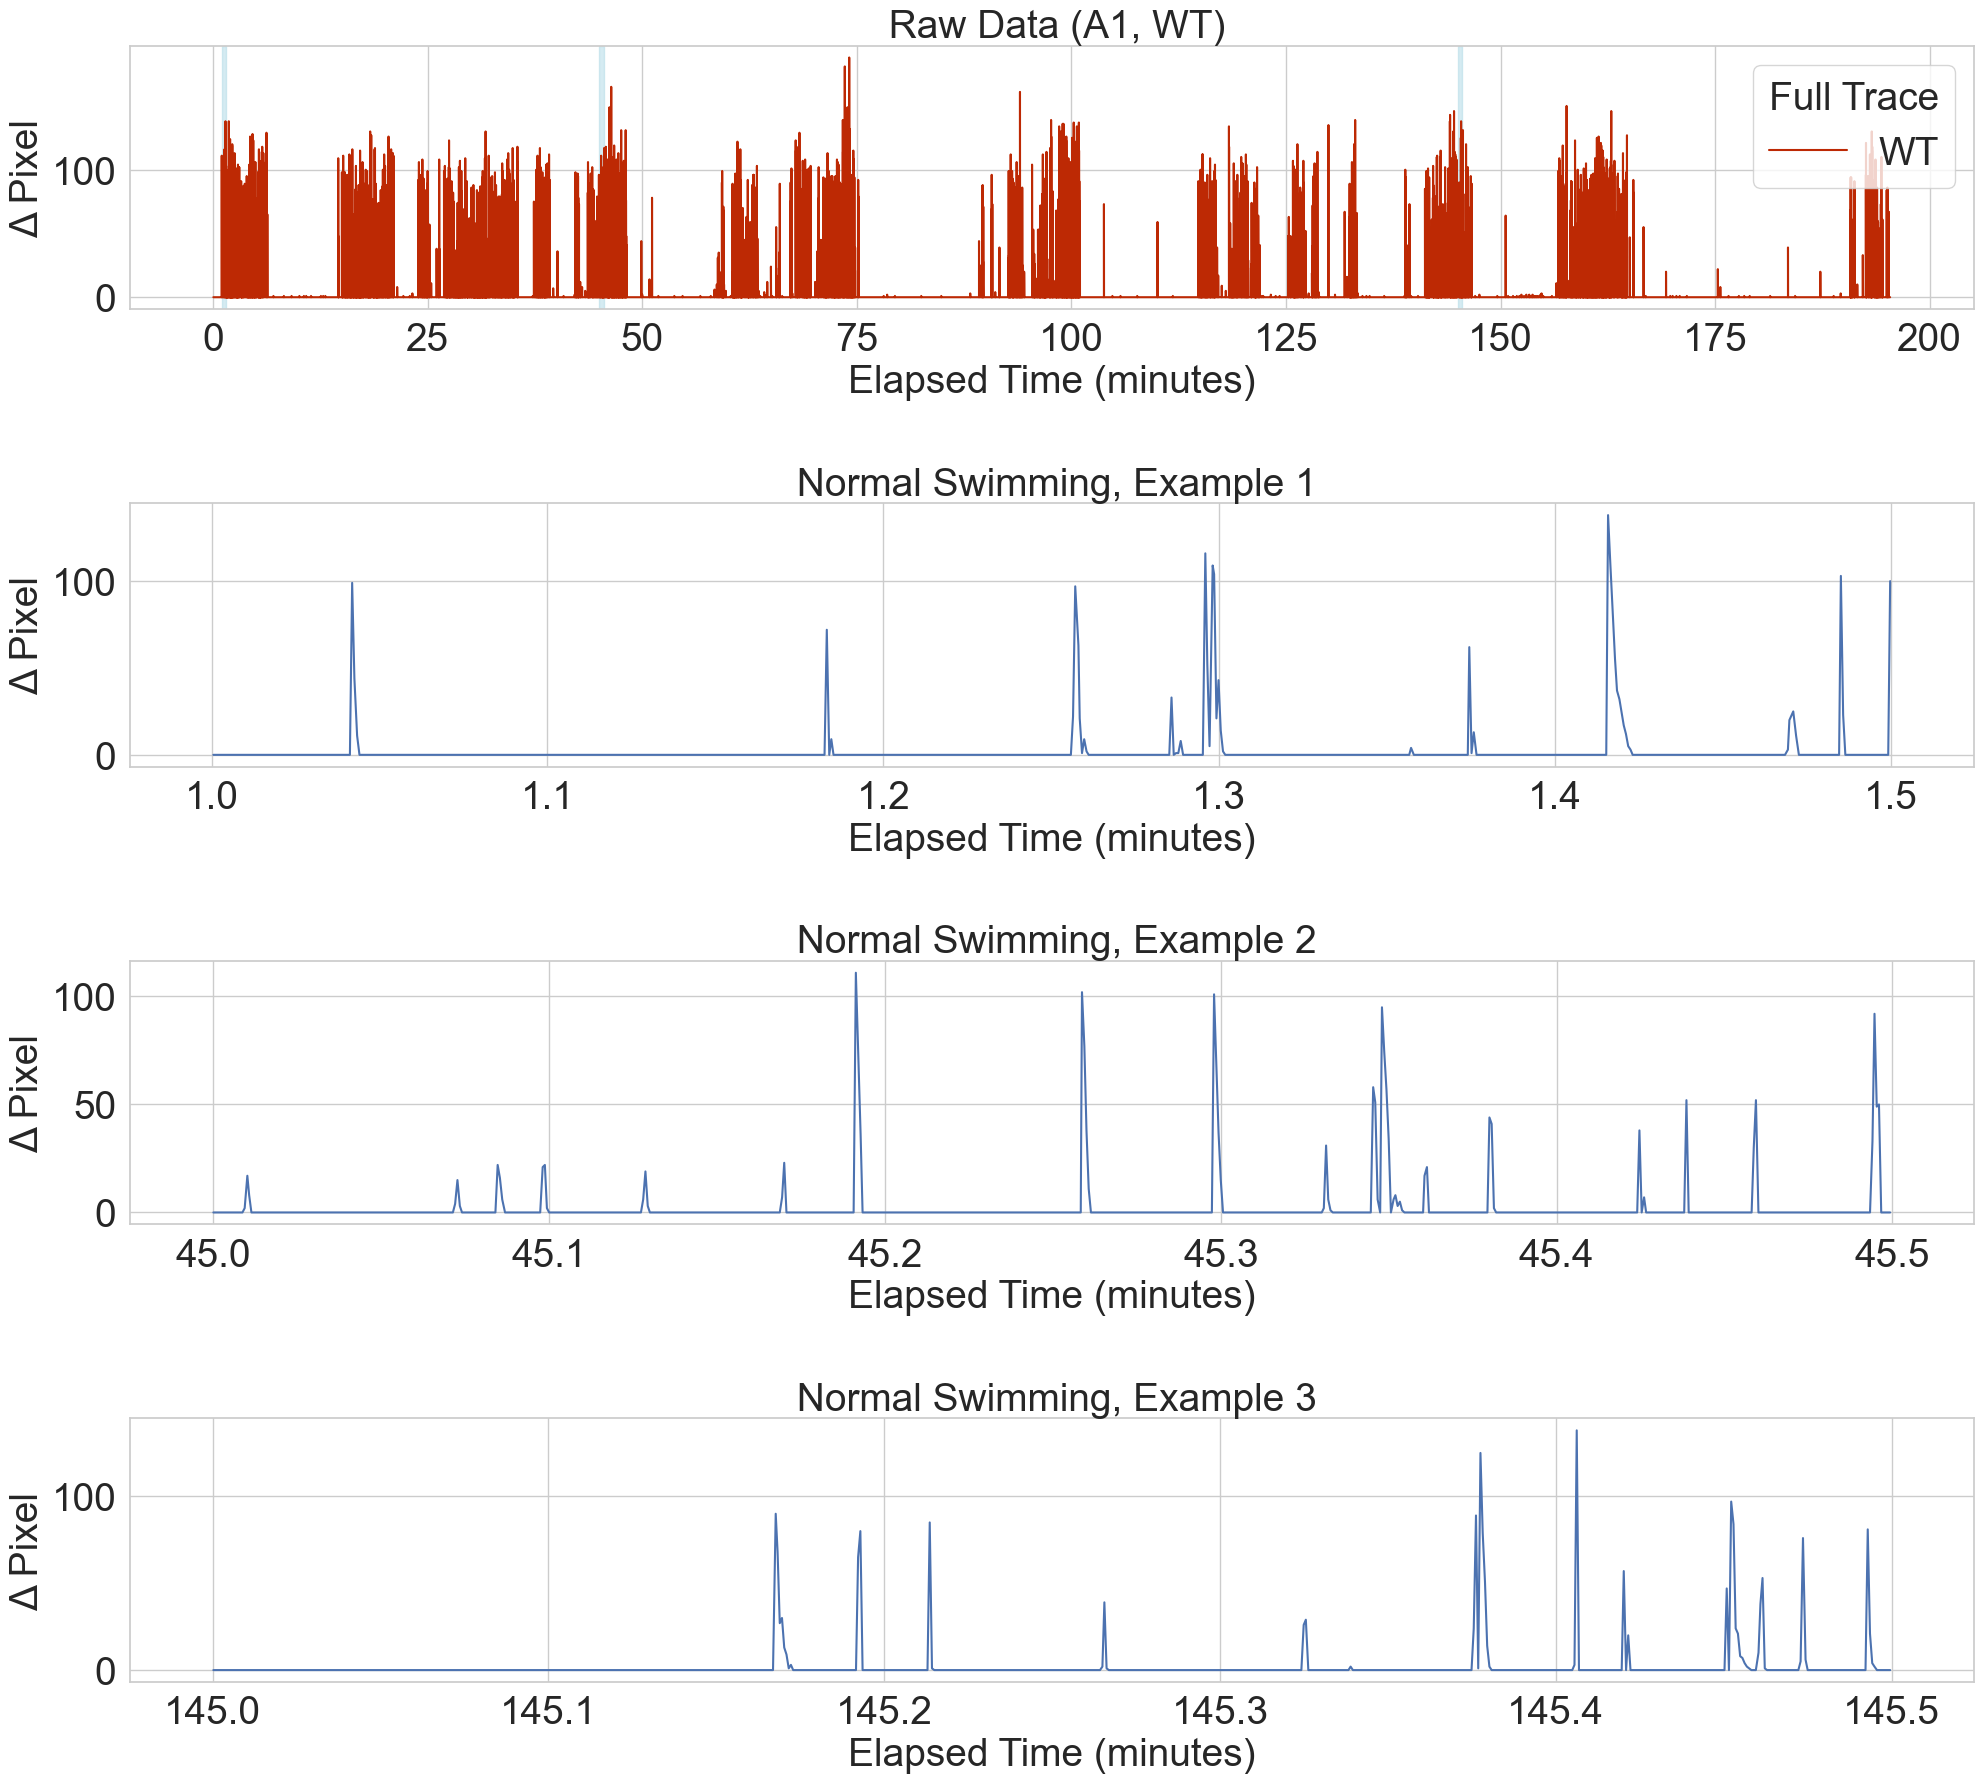

In [16]:
ald_lys_obj_raw.plot_single_fish_activity(well='A1', event_windows=[
    (1, 1.5, "Normal Swimming, Example 1"),
    (45, 45.5, "Normal Swimming, Example 2"),
    (145, 145.5, "Normal Swimming, Example 3")
])

Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_single_plot_D6.svg


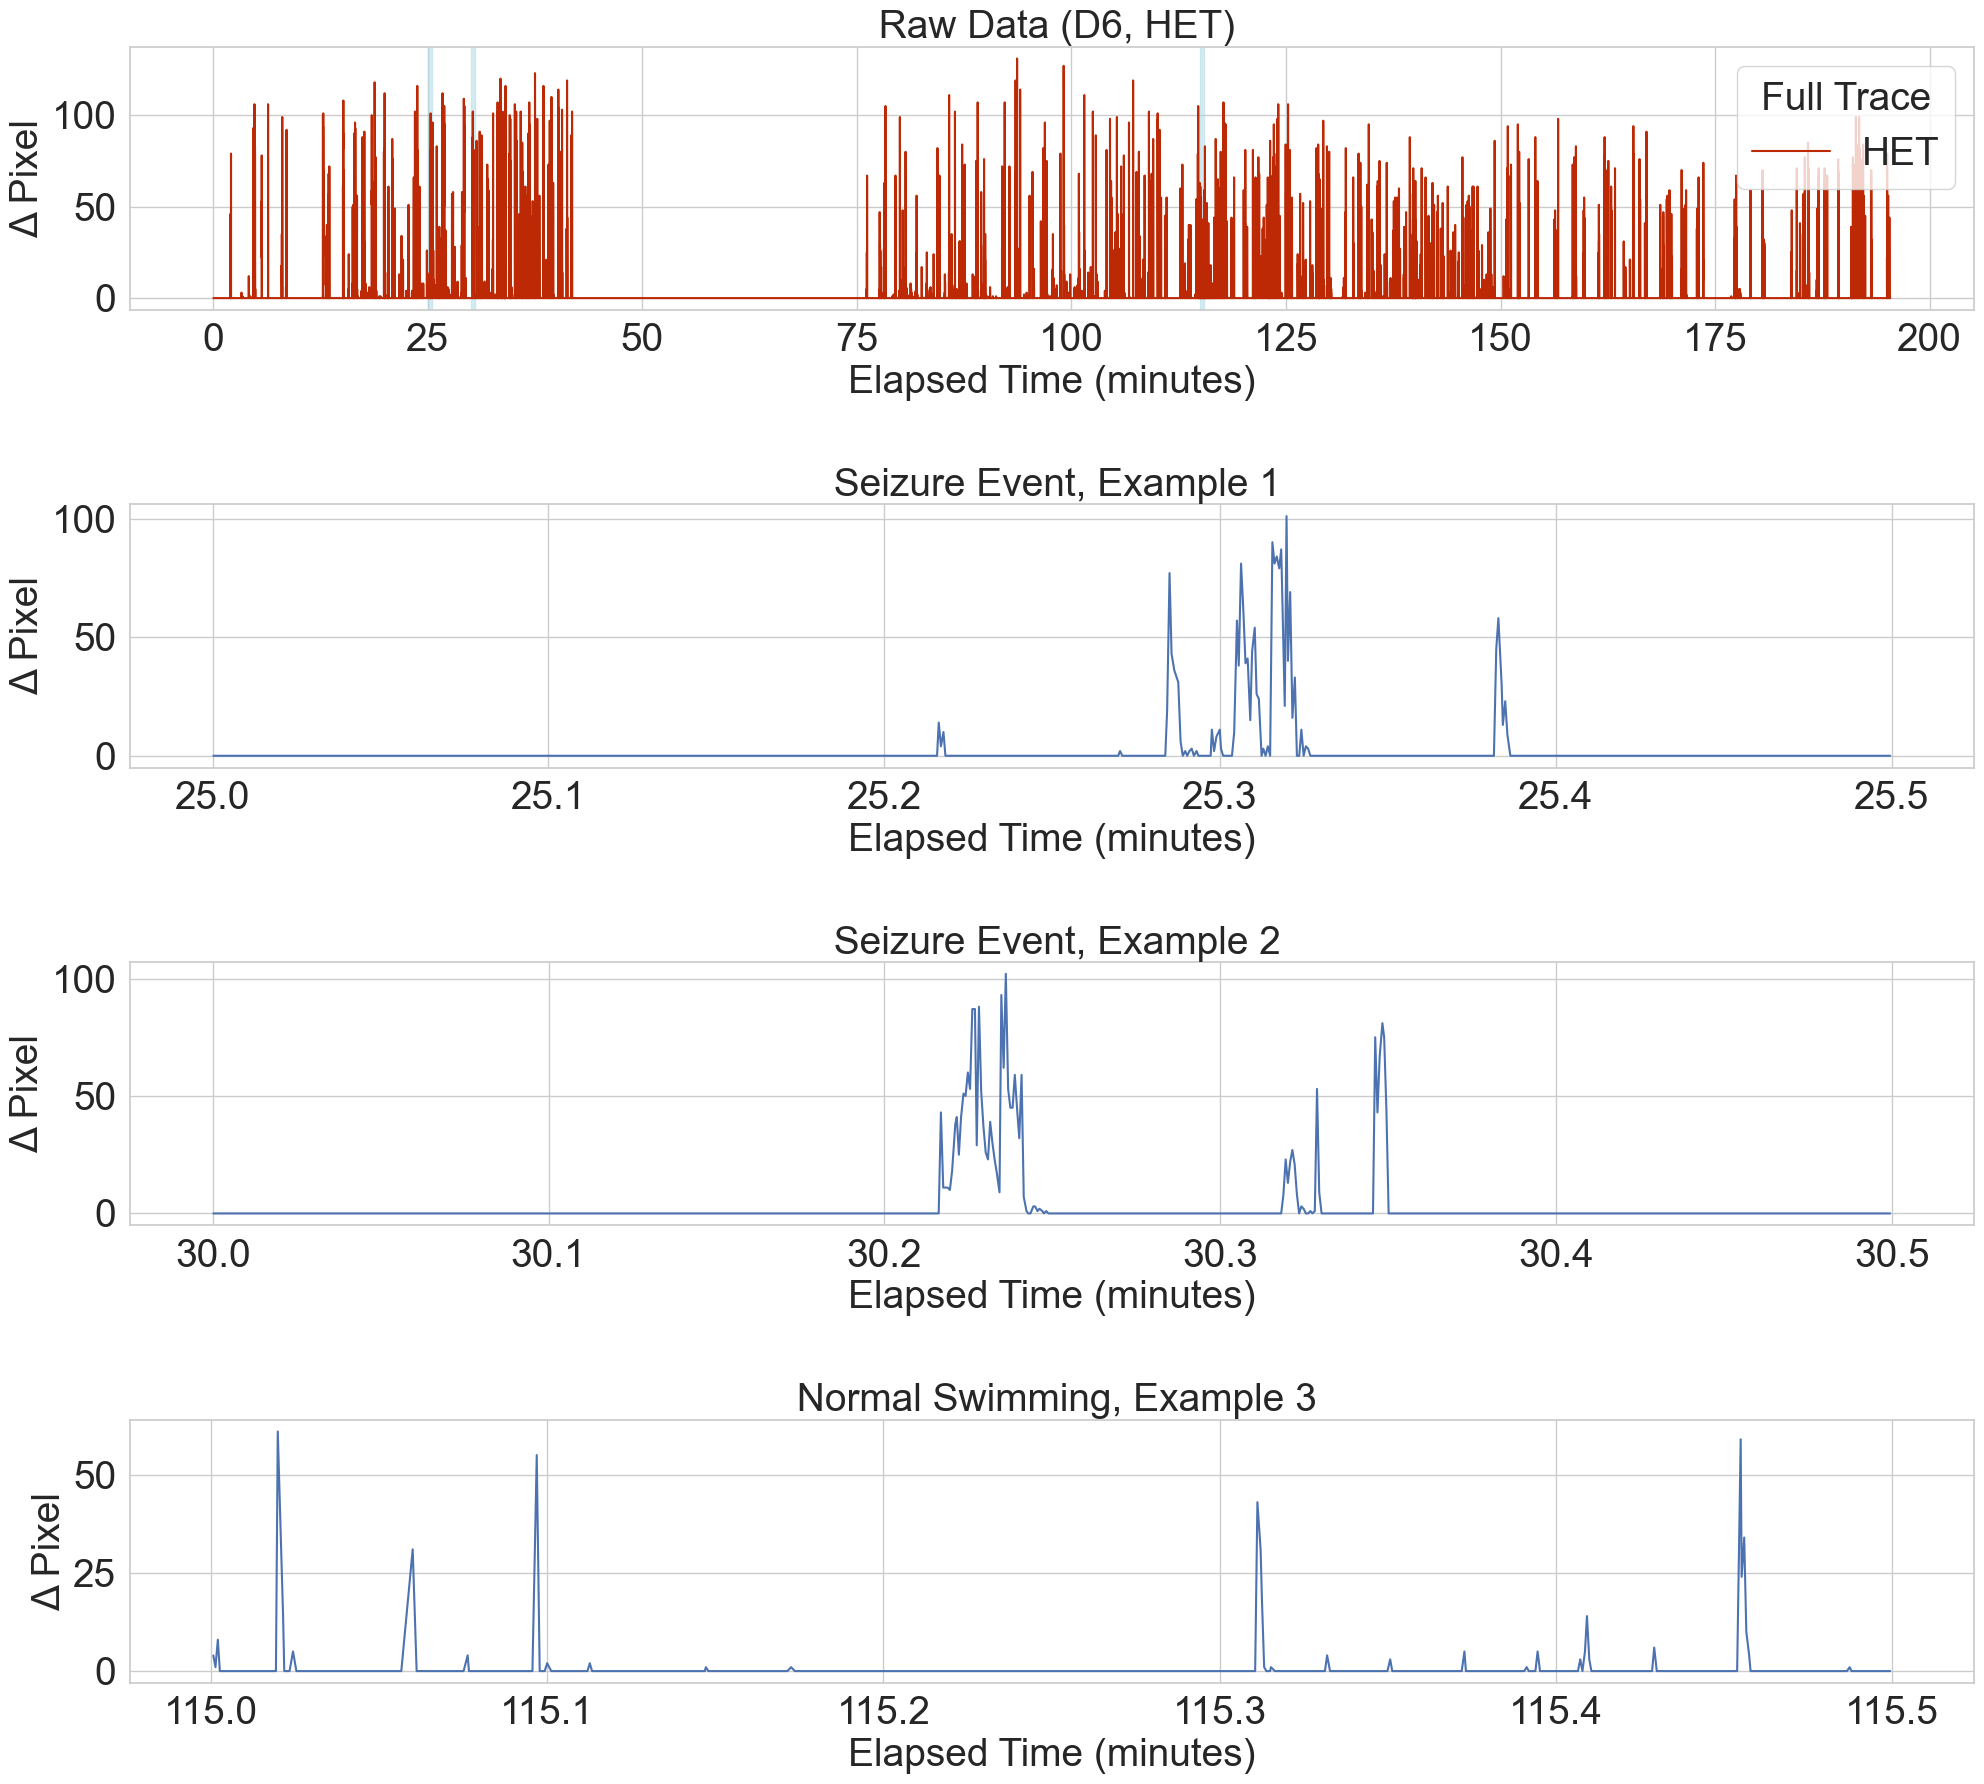

In [15]:
ald_lys_obj_raw.plot_single_fish_activity(well='D6', event_windows=[
    (25, 25.5, "Seizure Event, Example 1"),
    (30, 30.5, "Seizure Event, Example 2"),
    (115, 115.5, "Normal Swimming, Example 3")
])

Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_single_plot_E6.svg


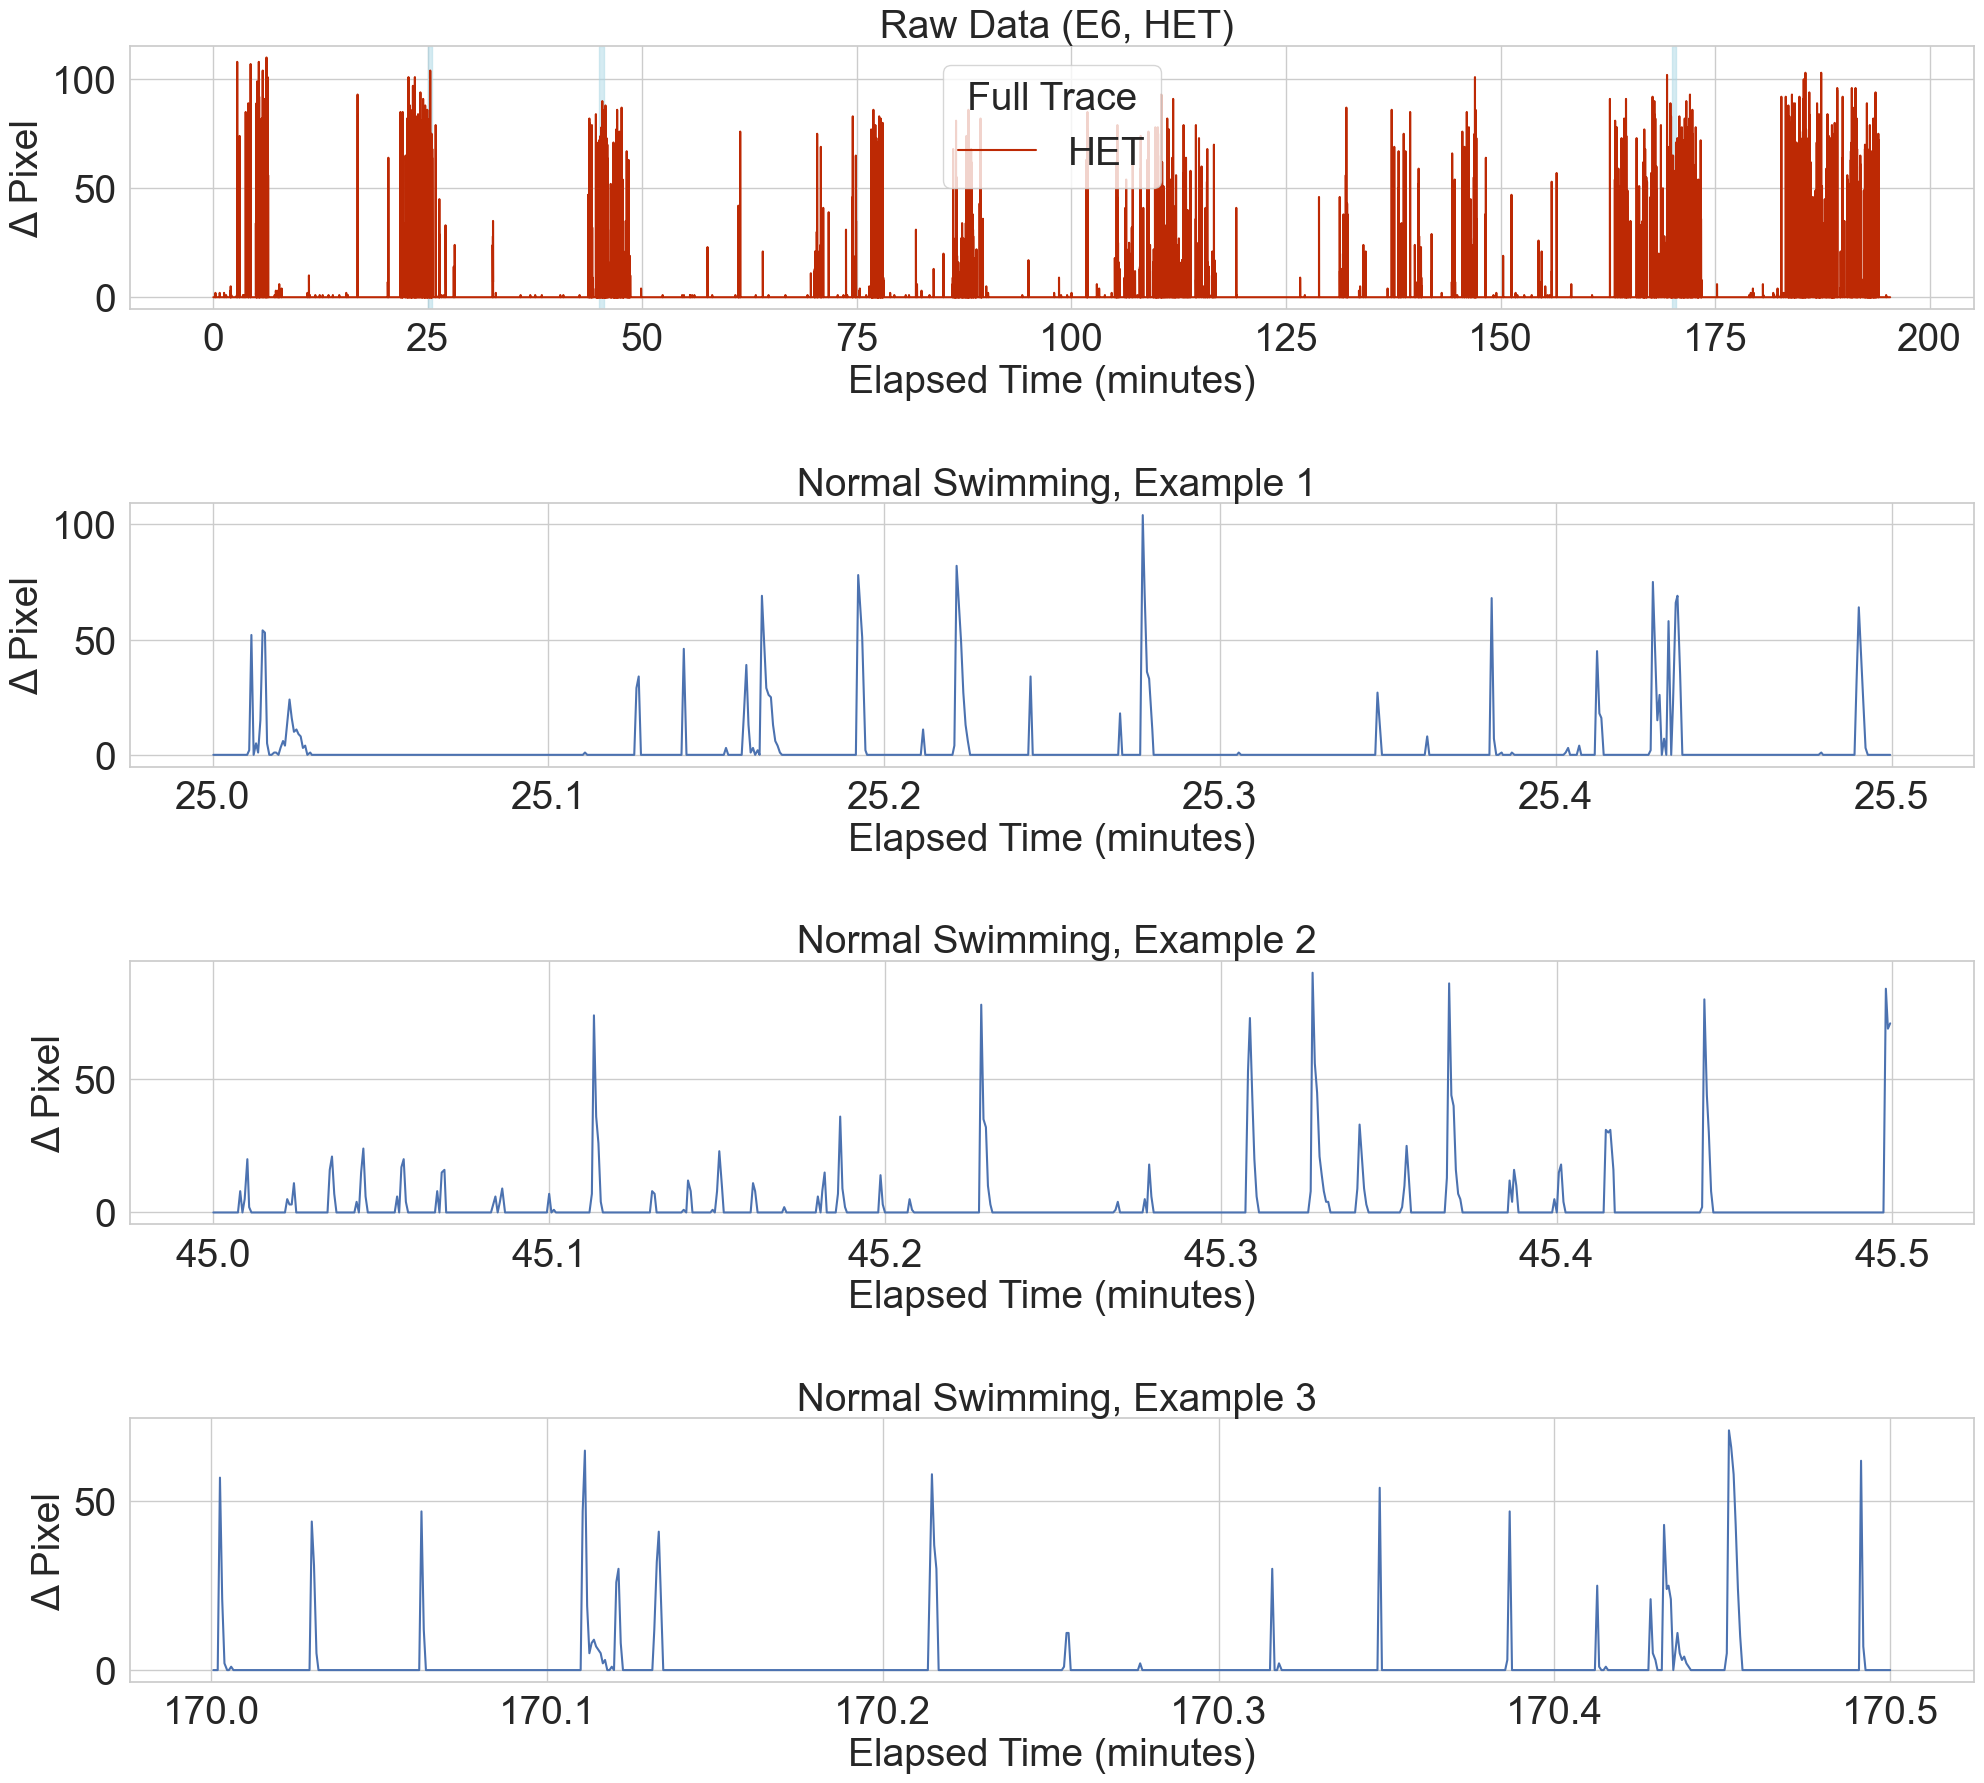

In [14]:
ald_lys_obj_raw.plot_single_fish_activity(well='E6', event_windows=[
    (25, 25.5, "Normal Swimming, Example 1"),
    (45, 45.5, "Normal Swimming, Example 2"),
    (170, 170.5, "Normal Swimming, Example 3")
])


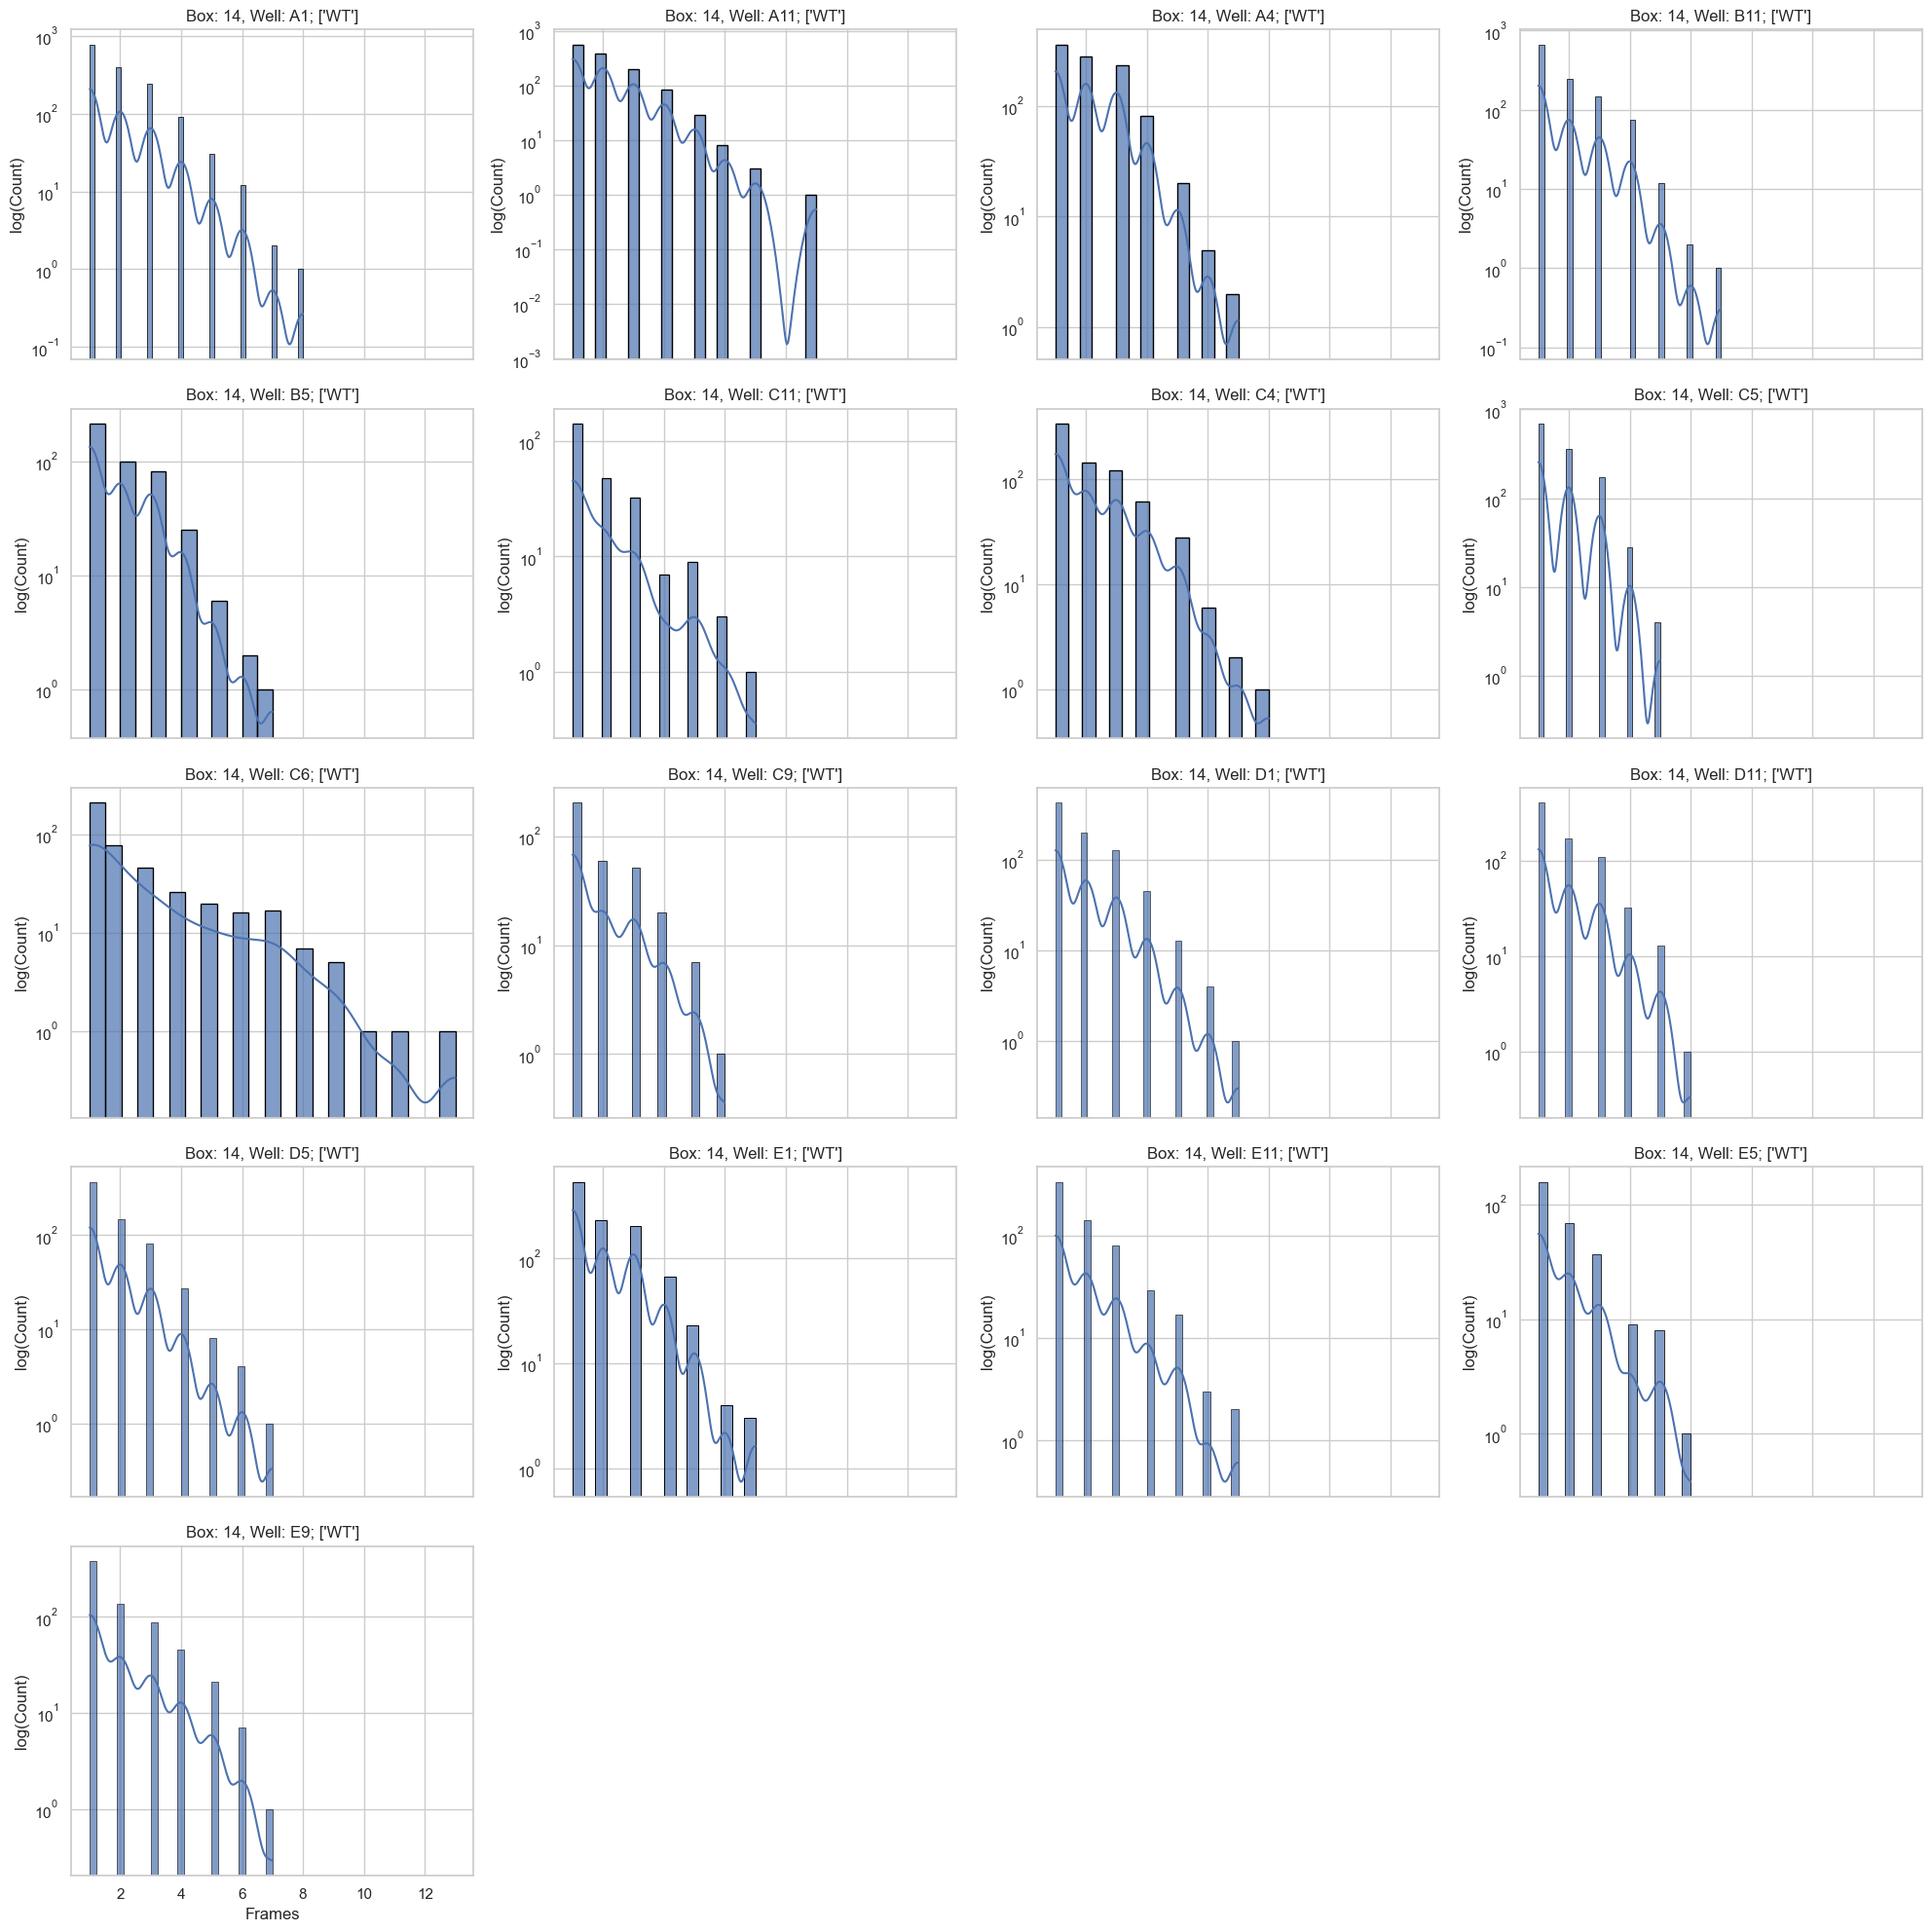

In [257]:
all_wts = df_raw[df_raw["genotype"] == "WT"]
all_wts_grouped = list(all_wts.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_wts_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)


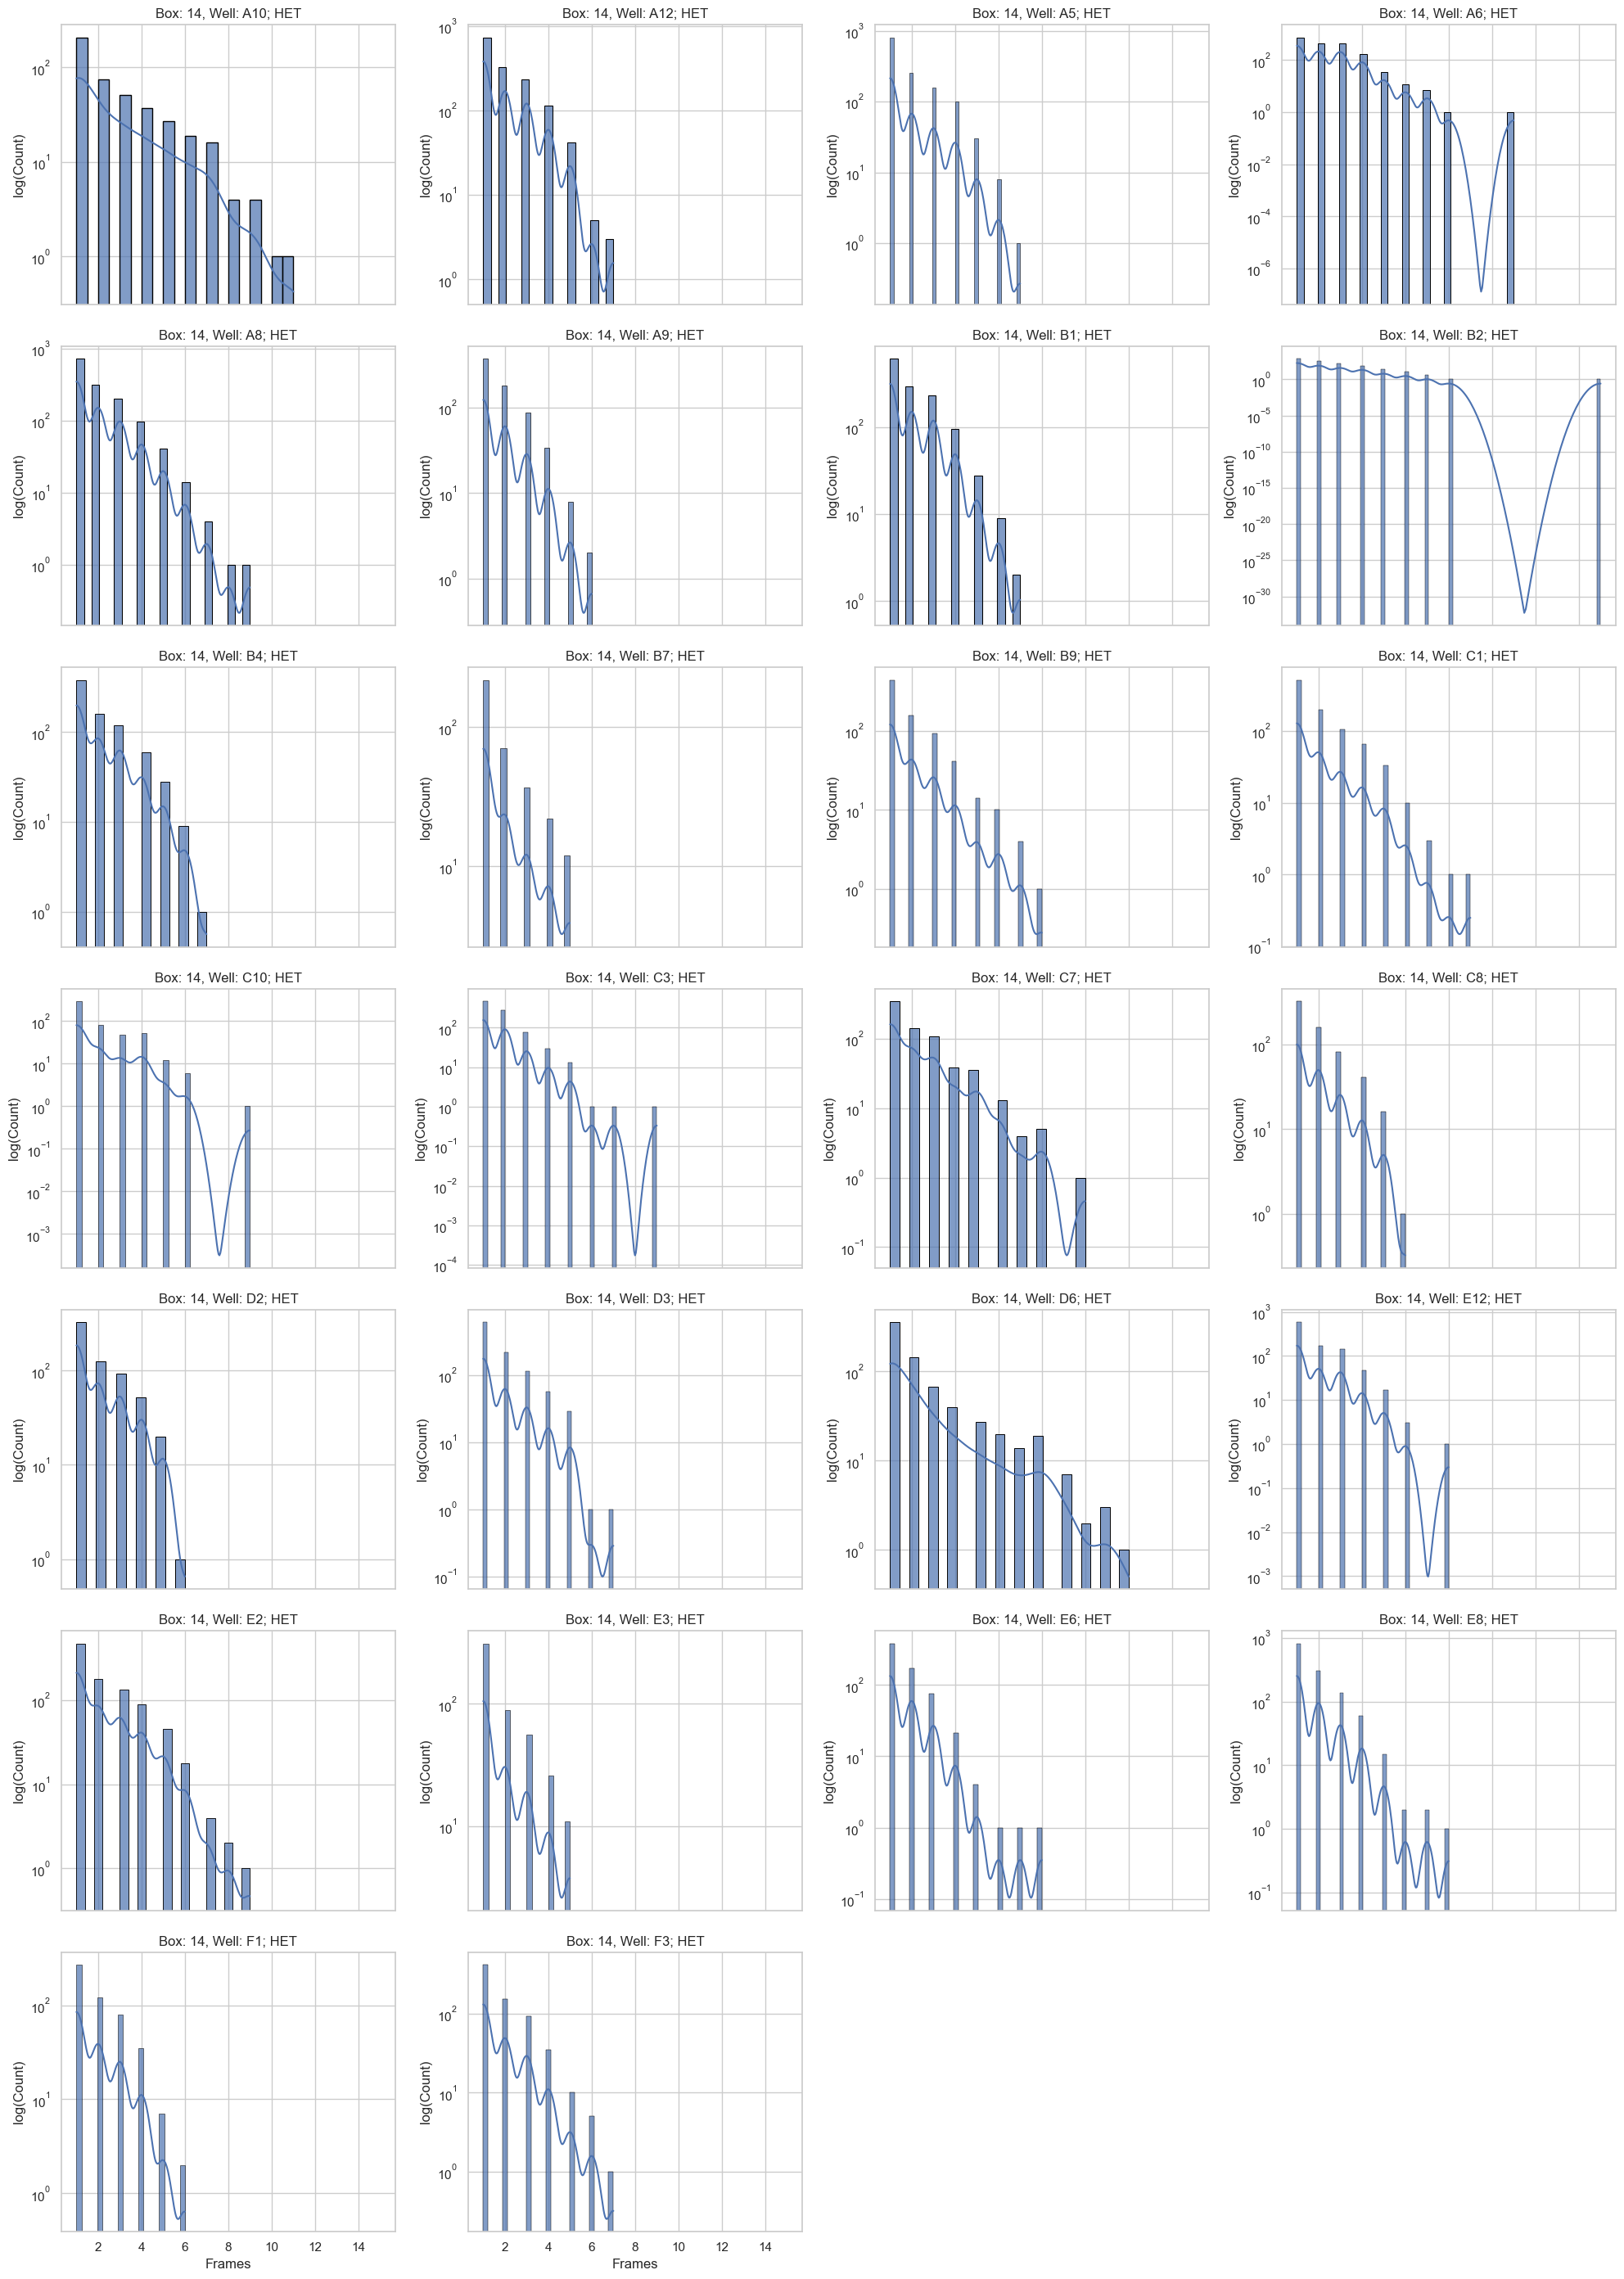

In [249]:
all_hets = df_raw[df_raw["genotype"] == "HET"]
all_hets_grouped = list(all_hets.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_hets_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

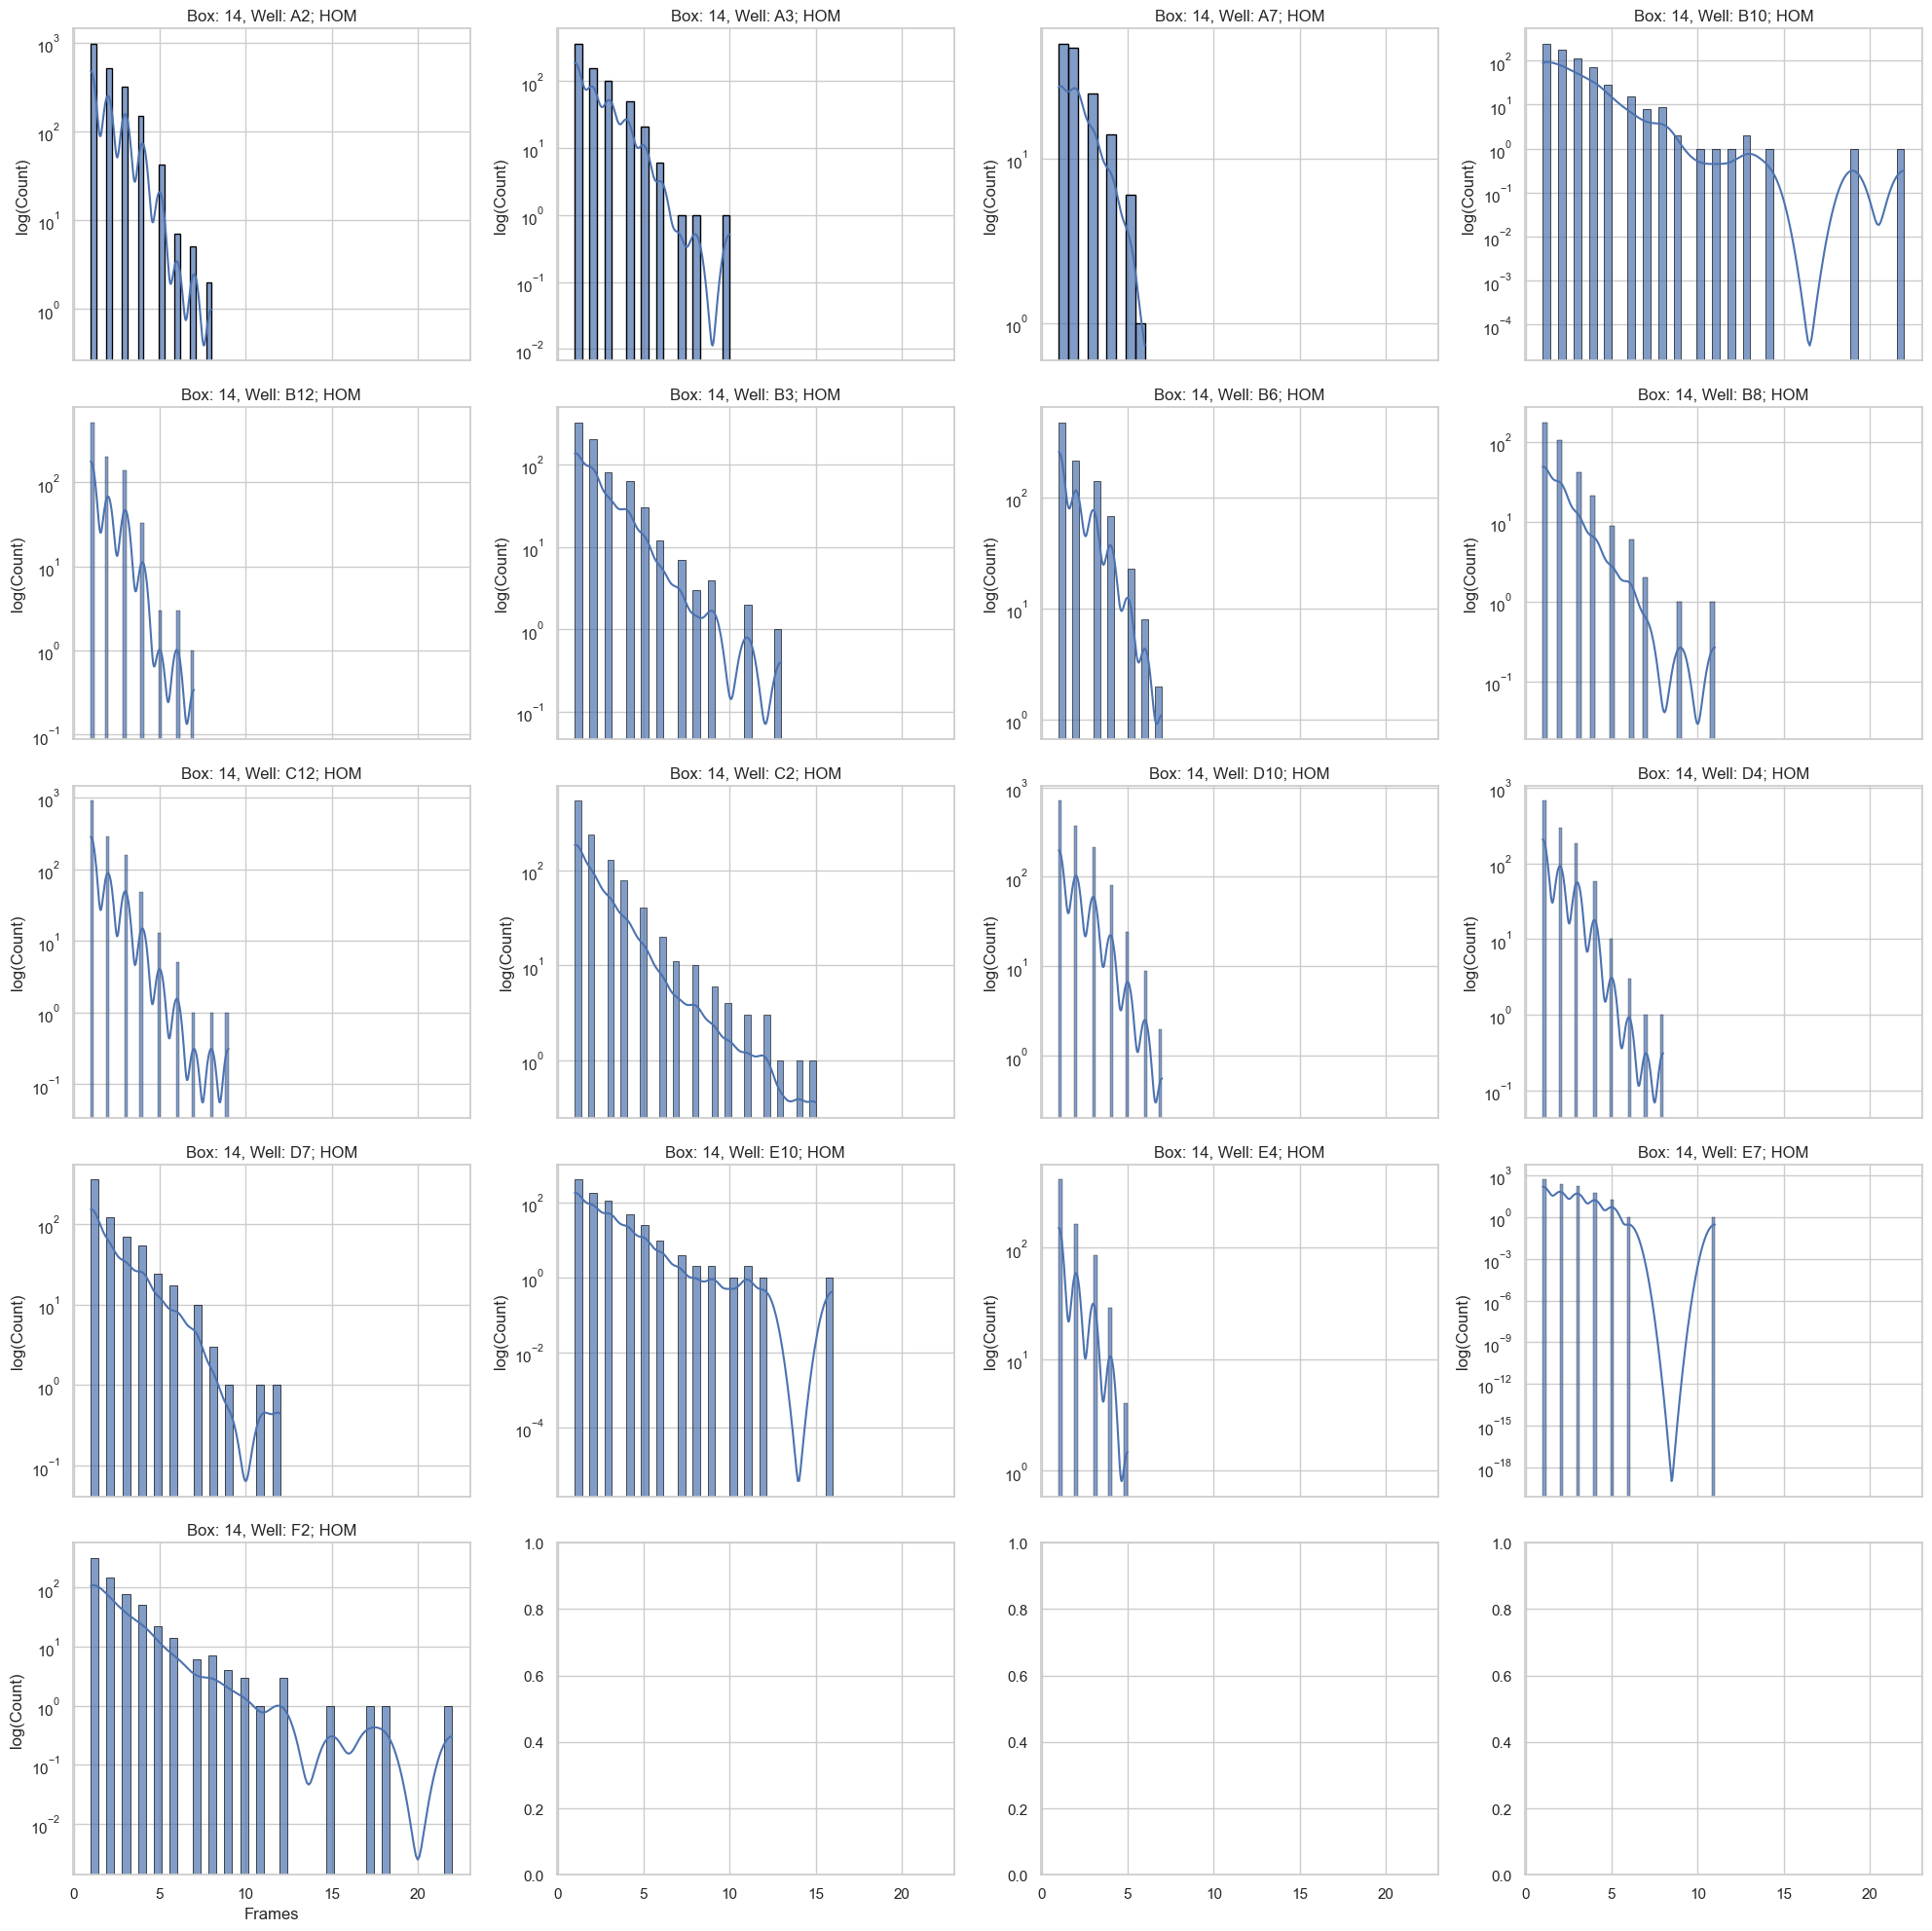

In [262]:
all_homs = df_raw[df_raw["genotype"] == "HOM"]
all_homs_grouped = list(all_homs.groupby(["box", "well"]))

# Extract (box, well) tuples
fish_list = [key for key, _ in all_homs_grouped]

# Pass all fish at once
ald_lys_obj_raw.plot_fish_count_hist(box_well_list=fish_list)

In [23]:



fishA1        = df_raw[df_raw['well'] == 'A1'] #WT

# Define threshold
threshold = 40

# Ensure data is sorted by time
df = fishA1.sort_values(by="fullts")

# Create a boolean column indicating if data1 is above the threshold
df["above_threshold"] = df["data1"] >= threshold

# Initialize variables
frame_count = 0
count_durations = []  # List to store number of frames in each threshold exceedance
above_threshold = False  # Track whether we're in a threshold-exceeding period

# Iterate through dataframe using .itertuples() (more efficient)
for row in df.itertuples(index=False):
    if row.above_threshold:
        if not above_threshold:  # First frame crossing threshold
            frame_count = 1  # Start counting
            above_threshold = True
        else:
            frame_count += 1  # Keep counting frames
    else:
        if above_threshold:  # Just dropped below threshold
            count_durations.append(frame_count)  # Store frame count
            above_threshold = False
            frame_count = 0  # Reset counter

# If the last value was still above the threshold, store the final count
if above_threshold:
    count_durations.append(frame_count)

# Output the frame count durations
print(f"Frame counts where data1 exceeded the threshold ({start}, {end}):", count_durations)
fishA1_count_durations = count_durations
ax = sns.histplot(fishA1_count_durations, kde=True, edgecolor="black", alpha=0.7)
ax.set_yscale("log")

NameError: name 'start' is not defined

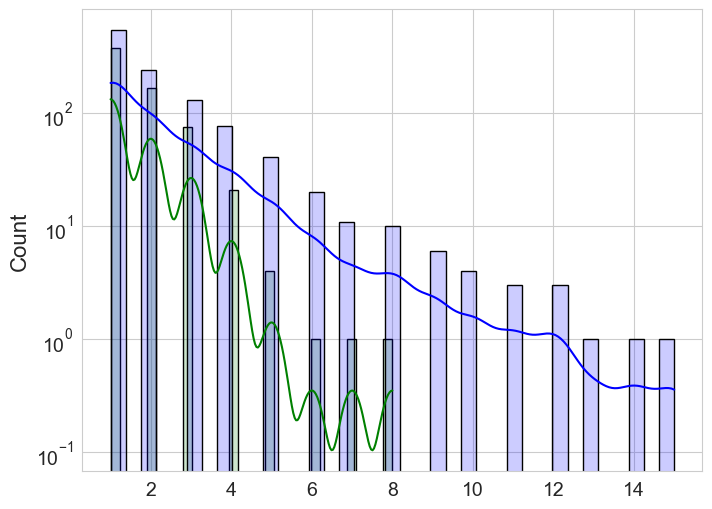

In [122]:
plt.figure(figsize=(8, 6))
    
# Plot first series
sns.histplot(hetE6_count_durations, kde=True, color="green", edgecolor="black", alpha=0.2, label='E6, HET')

# # Plot second series
sns.histplot(homC2_count_durations, kde=True, color="blue", edgecolor="black", alpha=0.2, label='C2, HOM')


plt.yscale("log")

plt.show()

Number of Seizure Events detected: 90 (C2, HOM)
Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_event_114407_114433_C2.svg


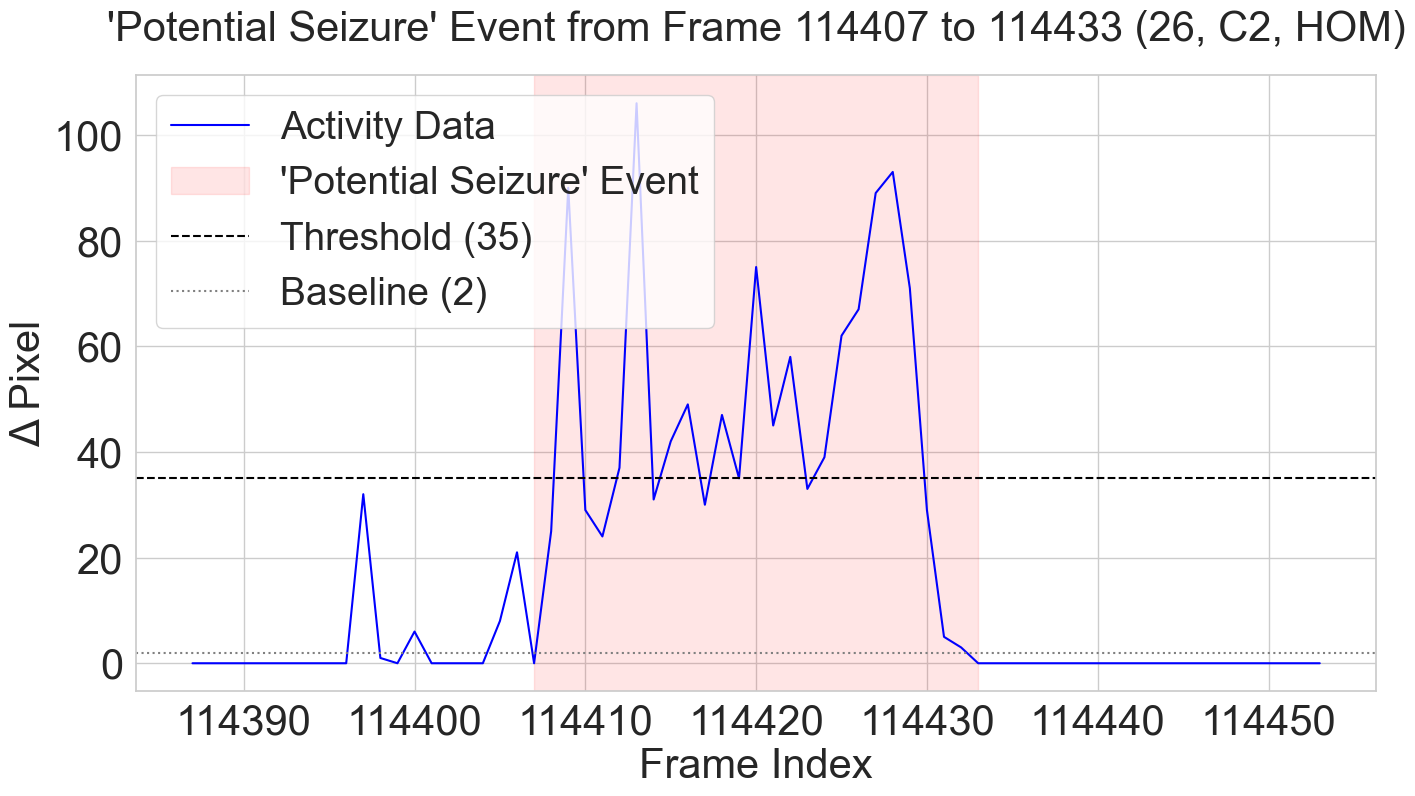

Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_event_96177_96256_C2.svg


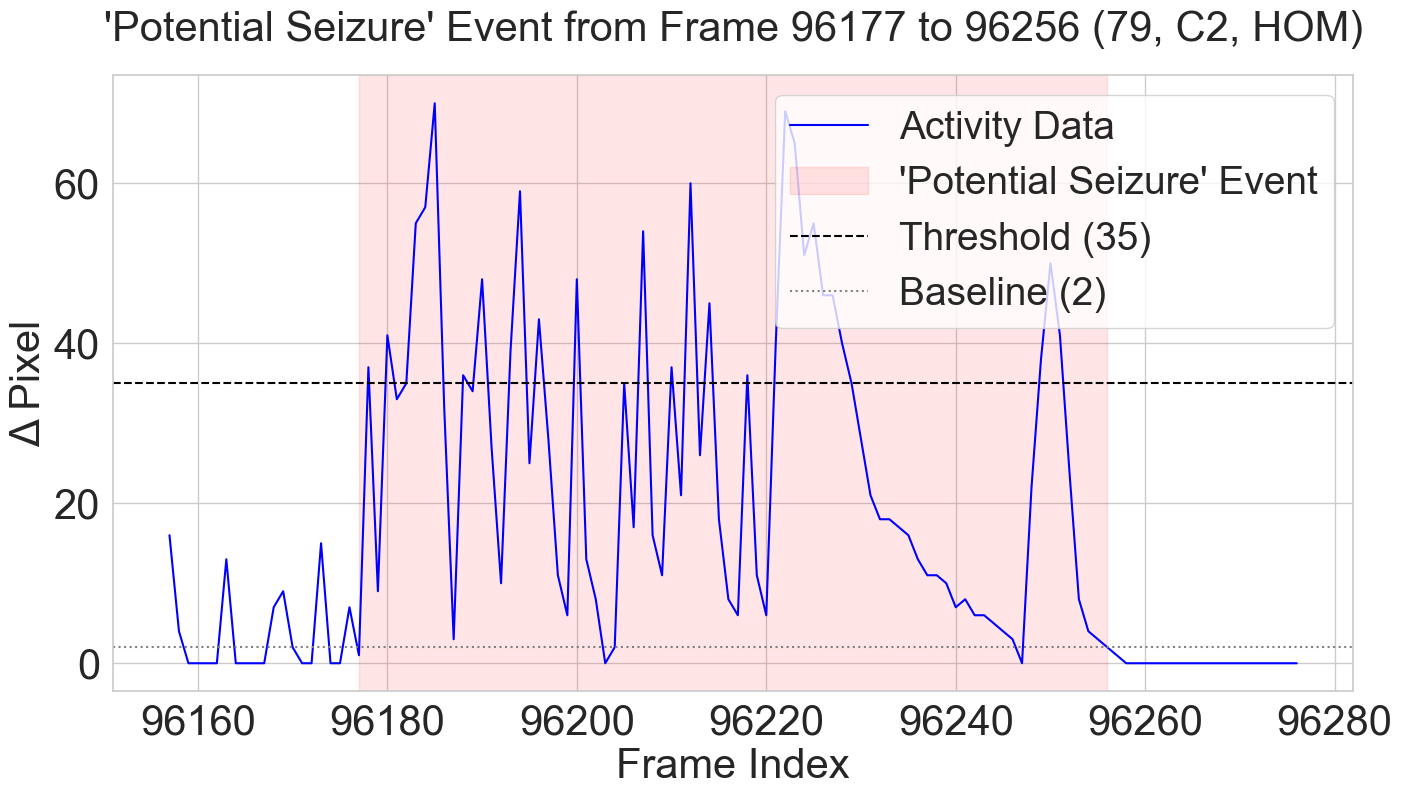

Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_event_249065_249103_C2.svg


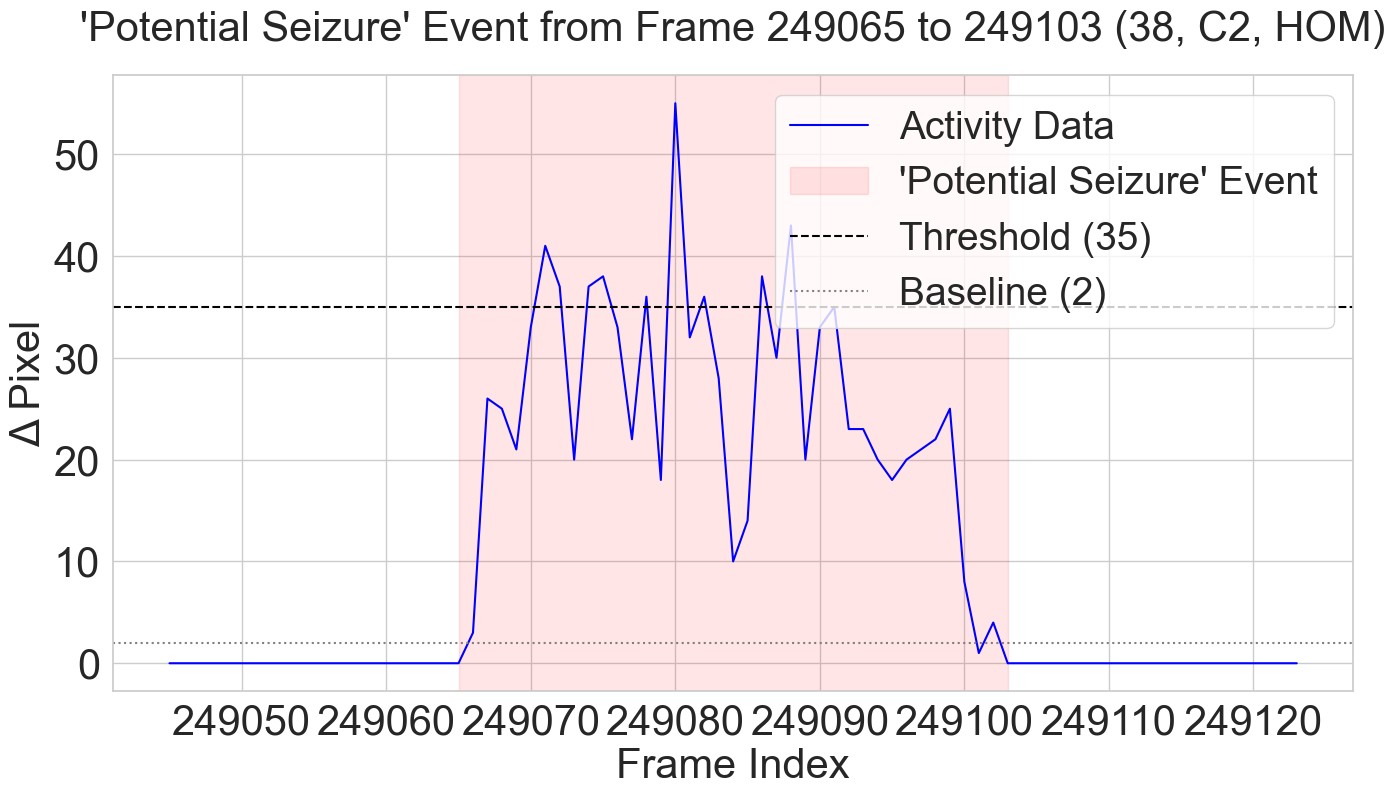

Plot saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_event_258611_258637_C2.svg


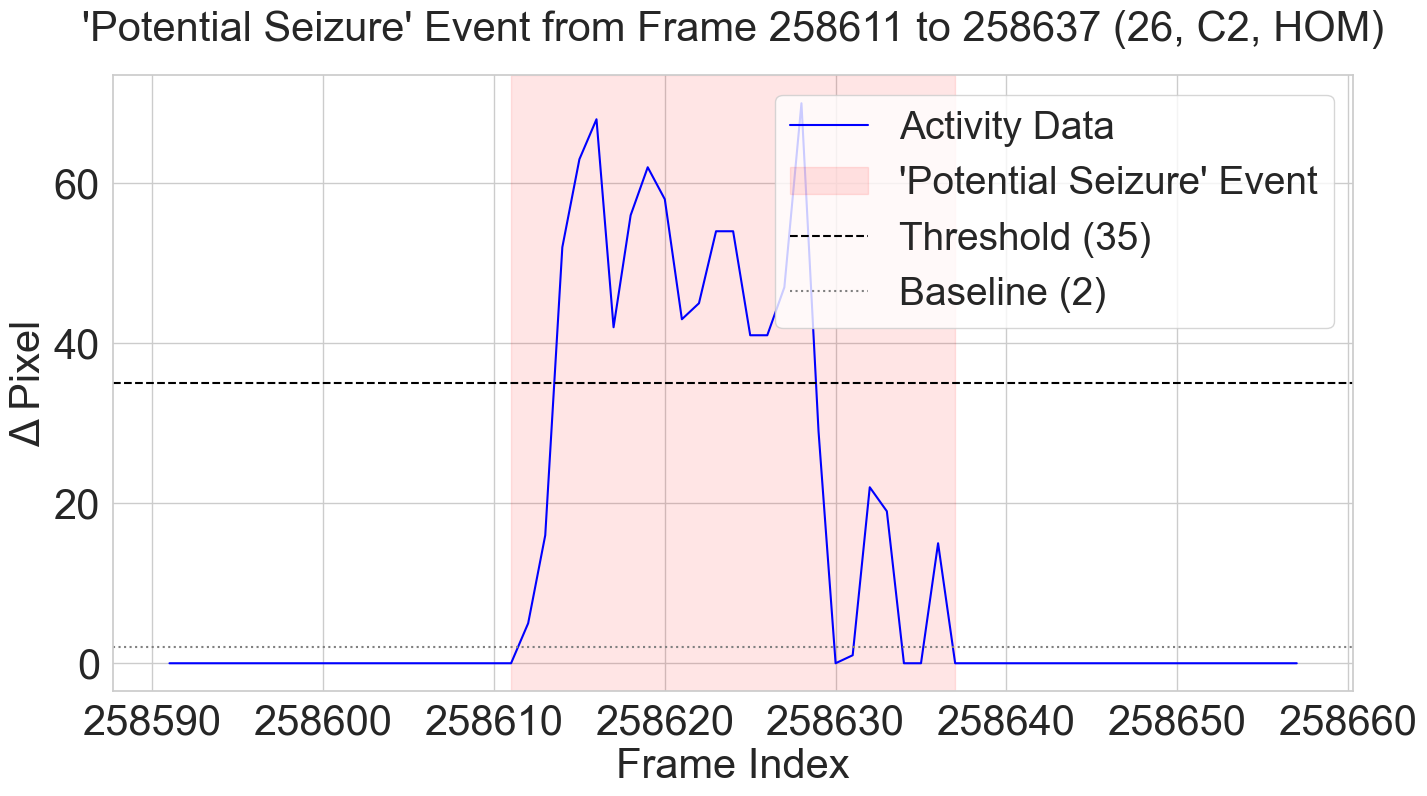

,start,end,duration,IBI
0,629,655,26,13
1,684,715,31,16
2,10950,10993,43,9
3,18834,18860,26,7
4,19019,19047,28,7
...,...,...,...,...
85,285857,285894,37,268
86,286995,287055,60,341
87,287839,287867,28,6
88,289775,289802,27,3


In [46]:
# fishA1 = df_raw[df_raw['well'] == 'A1'] #WT
# ald_lys_obj_raw.detect_seizures(fishA1, plot=True)

# fishD6 = df_raw[df_raw['well'] == 'D6'] #HET
# ald_lys_obj_raw.detect_seizures(fishD6, plot=True)

fishC2 = df_raw[df_raw['well'] == 'C2'] #HOM
ald_lys_obj_raw.detect_seizures(fishC2, plot=True)



In [6]:
import subprocess
import os

# Define base name and paths
# # Define input variables
# date   = "250214"
# box1   = "14"
# box2   = "15"
# exp    = "ALDH7A1_20LYS_7dpf"
# export = False

base_name = f"{date}_{box1}_{box2}_{exp}"
input_avi = f"{base_name}/{base_name}_Box1_0001.avi"
converted_mp4 = f"{base_name}/{base_name}_Box1_0001_converted.mp4"
output_dir = f"{base_name}/video_segments"
os.makedirs(output_dir, exist_ok=True)

# Step 1: Convert full AVI to MP4
if not os.path.exists(converted_mp4):
    print("🎬 Converting full AVI to MP4...")
    conversion_command = [
        "ffmpeg",
        "-i", input_avi,
        "-c:v", "libx264",
        "-c:a", "aac",
        "-movflags", "+faststart",
        "-y",  # Overwrite if exists
        converted_mp4
    ]
    subprocess.run(conversion_command, check=True)
else:
    print("✅ MP4 conversion already exists. Skipping.")

🎬 Converting full AVI to MP4...


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/7.1.1_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex

In [7]:
# 25/5/8 THIS WAS FOR TRIAL AND ERROR SUPERIMPOSING GENOTYPE MAP ON VID TO ACHEIVE IDEAL SIZE AND POSTION


# # Define input variables
# date   = "250214"
# box1   = "14"
# box2   = "15"
# exp    = "ALDH7A1_20LYS_7dpf"
# export = False

base_name = f"{date}_{box1}_{box2}_{exp}"

import cv2
from PIL import Image

# === Configuration ===
video_path = f"{base_name}/{base_name}_Box1_0001_converted.mp4"
# video_path = f"{base_name}/{base_name}.m4v"
overlay_image_path = f"{base_name}/{base_name}.png"  # Can be .png for transparency
output_path = f"{base_name}/{base_name}_geno_overlay.mp4"

# === Step 1: Extract first frame ===
cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

if not success:
    raise ValueError("Could not read frame from video")

# Convert OpenCV BGR to RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_pil = Image.fromarray(frame_rgb)

# === Step 2: Load overlay image ===
overlay = Image.open(overlay_image_path).convert("RGBA")

# Apply 50% opacity
alpha = overlay.split()[3]  # Get the alpha channel
alpha = alpha.point(lambda p: p * 0.1)  # Reduce opacity to 50%
overlay.putalpha(alpha)

# (Optional) Resize overlay here, e.g.:
overlay = overlay.resize((2250, 840))

# Define overlay position
position = (-1070, 130)  # Top-left corner, change as needed

# === Step 3: Paste overlay ===
frame_pil.paste(overlay, position, overlay)

# === Step 4: Save the result ===
frame_pil.save(output_path)
print(f"Saved output image to: {output_path}")

ValueError: unknown file extension: .mp4

In [4]:
import os
import cv2
from PIL import Image
import multiprocessing
import shutil
import subprocess


base_name = f"{date}_{box1}_{box2}_{exp}"

# === CONFIGURATION ===
video_path = f"{base_name}/{base_name}_Box1_0001_converted.mp4"
overlay_path = f"{base_name}/{base_name}.png"
output_video_path =  f"{base_name}/{base_name}_geno_overlay.mp4"

# === Configuration ===
# video_path = f"{base_name}/{base_name}_Box1_0001_converted.mp4"
# # video_path = f"{base_name}/{base_name}.m4v"
# overlay_path = f"{base_name}/{base_name}.png"  # Can be .png for transparency
# output_path = f"{base_name}/{base_name}_geno_overlay.mp4"


temp_dir = 'temp_video_processing'
raw_frames_dir = os.path.join(temp_dir, 'frames_raw')
processed_frames_dir = os.path.join(temp_dir, 'frames_processed')

# === CLEAN TEMP FOLDERS ===
for folder in [raw_frames_dir, processed_frames_dir]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# === STEP 1: Extract frames ===
print("Extracting frames...")
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_path = os.path.join(raw_frames_dir, f"frame_{frame_count:05d}.png")
    cv2.imwrite(frame_path, frame)
    frame_count += 1

cap.release()
print(f"Extracted {frame_count} frames.")

# === STEP 2: Prepare overlay image ===
overlay_image = Image.open(overlay_path).convert("RGBA")
overlay_image = overlay_image.resize((2250, 840))
alpha = overlay_image.split()[3]
alpha = alpha.point(lambda p: p * 0.1)  # 10% opacity
overlay_image.putalpha(alpha)

# Save preprocessed overlay image to avoid reloading it in every process
overlay_image.save(os.path.join(temp_dir, 'prepared_overlay.png'))

# === STEP 3: Process frames in parallel ===
def apply_overlay_to_frame(frame_path):
    from PIL import Image  # Re-import inside subprocess
    overlay = Image.open(os.path.join(temp_dir, 'prepared_overlay.png')).convert("RGBA")
    frame = Image.open(frame_path).convert("RGBA")
    frame.paste(overlay, (-1070, 130), overlay)
    frame = frame.convert("RGB")
    out_path = os.path.join(processed_frames_dir, os.path.basename(frame_path))
    frame.save(out_path)

print("Applying overlay in parallel...")
frame_files = sorted(os.listdir(raw_frames_dir))
frame_paths = [os.path.join(raw_frames_dir, f) for f in frame_files]

with multiprocessing.Pool() as pool:
    pool.map(apply_overlay_to_frame, frame_paths)

print("Finished overlay processing.")

# === STEP 4: Rebuild video ===
print("Reassembling video...")
sample_frame = cv2.imread(os.path.join(processed_frames_dir, frame_files[0]))
height, width, _ = sample_frame.shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

for filename in frame_files:
    frame = cv2.imread(os.path.join(processed_frames_dir, filename))
    out.write(frame)

out.release()
print(f"Video saved: {output_video_path}")

# === STEP 5: Merge audio with ffmpeg (requires ffmpeg installed) ===
# print("Merging original audio using ffmpeg...")
# subprocess.run([
#     'ffmpeg',
#     '-y',
#     '-i', output_video_path,
#     '-i', video_path,
#     '-c:v', 'copy',
#     '-c:a', 'aac',
#     '-map', '0:v:0',
#     '-map', '1:a:0',
#     final_video_path
# ])

# print(f"Final video with audio saved: {final_video_path}")

Extracting frames...


libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error
libpng error: Write Error


Extracted 287619 frames.


OSError: [Errno 28] No space left on device: 'temp_video_processing/prepared_overlay.png'

In [6]:
import cv2
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from tqdm import tqdm

# === Paths ===

base_name = f"{date}_{box1}_{box2}_{exp}"
video_path = f"{base_name}/{base_name}_Box1_0001_converted.mp4"
overlay_image_path = f"{base_name}/{base_name}.png"
output_video_path = f"{base_name}/{base_name}_Box1_0001_overlay.mp4"

# === Load overlay and prepare it ===
overlay = Image.open(overlay_image_path).convert("RGBA")
overlay = overlay.resize((2250, 840))

alpha = overlay.split()[3]
alpha = alpha.point(lambda p: p * 0.1)  # 10% opacity
overlay.putalpha(alpha)

# === Setup video input/output ===
cap = cv2.VideoCapture(video_path)
fps = 25.0  # Force correct FPS
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

# === Setup font for frame number ===
try:
    font = ImageFont.truetype("arial.ttf", 28)
except IOError:
    font = ImageFont.load_default()

# === Frame-by-frame processing ===
print(f"Processing {frame_count} frames...")
for frame_num in tqdm(range(frame_count), desc="Processing"):
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_pil = Image.fromarray(frame_rgb).convert("RGBA")

    # Overlay image
    frame_pil.paste(overlay, (-1070, 130), overlay)

    # Draw frame number
    draw = ImageDraw.Draw(frame_pil)
    text = f"Frame {frame_num:05d}"
    
    # Use textbbox instead of textsize (future-proof)
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    x = width - text_width - 20
    y = height - text_height - 20
    
    draw.text((x, y), text, font=font, fill=(255, 255, 255, 255))

    # Convert back to OpenCV and write
    frame_bgr = cv2.cvtColor(np.array(frame_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    out.write(frame_bgr)

cap.release()
out.release()
print(f"✅ Done! Output saved to: {output_video_path}")

Processing 287619 frames...


Processing: 100%|███████████████████████| 287619/287619 [54:40<00:00, 87.67it/s]

✅ Done! Output saved to: 250214_14_15_ALDH7A1_20LYS_7dpf/250214_14_15_ALDH7A1_20LYS_7dpf_Box1_0001_overlay.mp4


In [7]:
all_seizure_df = para_obj_raw.generate_all_seizure_df()

NameError: name 'para_obj_raw' is not defined